
# Sesión 02 — Modelos de Clasificación
**Ingeniería del Conocimiento (ISO56B)** · UNCP · 2026-II

**Docente:** Msc. Jaime Antonio Huaytalla Pariona

**Dataset:** Breast Cancer Wisconsin (569 muestras, 30 features, clasificación binaria)

---

## 1. Configuración del entorno

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, auc,
    roc_auc_score, make_scorer
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import subprocess, sys
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('✓ Librerías cargadas correctamente')

✓ Librerías cargadas correctamente


---
## 2. Carga y exploración del dataset

El dataset **Loan Prediction** contiene 614 solicitudes de préstamo con datos del solicitante (género, estado civil, dependientes, educación, empleo, ingresos), del préstamo (monto y plazo), historial crediticio y zona de la propiedad. El target es binario: **rechazado (0)** o **aprobado (1)**.

Diferencias importantes respecto al dataset original de la sesión:
- Mezcla variables **numéricas y categóricas** → se necesita codificación (One-Hot).
- Tiene **valores faltantes** → se imputan dentro del Pipeline (así no hay fuga de datos en la validación cruzada).
- Las clases están **desbalanceadas** (aprox. 69 % aprobado / 31 % rechazado), lo que da sentido real al Ejercicio 2.

In [7]:
# ══ EJERCICIO 3 · Dataset propio + modelos adicionales ═════════════
# Dataset propio: Loan Prediction (614 registros, 11 features)
URL = 'https://raw.githubusercontent.com/dsrscientist/DSData/master/loan_prediction.csv'

df = pd.read_csv(URL)

# Loan_ID es solo un identificador: no aporta información predictiva
df = df.drop(columns='Loan_ID')

# Target: 1 = Aprobado (Y), 0 = Rechazado (N)
CLASS_NAMES = ['Rechazado', 'Aprobado']
df['target'] = df['Loan_Status'].map({'N': 0, 'Y': 1})
df['estado'] = df['target'].map({0: 'Rechazado', 1: 'Aprobado'})
df = df.drop(columns='Loan_Status')

# Variables predictoras
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
cat_cols = ['Gender', 'Married', 'Dependents', 'Education',
            'Self_Employed', 'Credit_History', 'Property_Area']

print(f'Dataset: {df.shape[0]} muestras, {len(num_cols) + len(cat_cols)} features')
print(f'\nDistribución de clases:')
print(df['estado'].value_counts())
print(f'\nProporción: {df["target"].mean():.1%} aprobado, {1-df["target"].mean():.1%} rechazado')

Dataset: 614 muestras, 11 features

Distribución de clases:
estado
Aprobado     422
Rechazado    192
Name: count, dtype: int64

Proporción: 68.7% aprobado, 31.3% rechazado


In [8]:
# Estadísticos de las variables numéricas
df[num_cols].describe().round(3)

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
count,614.000,614.000,592.000,600.00
mean,5403.459,1621.246,146.412,342.00
std,6109.042,2926.248,85.587,65.12
min,150.000,0.000,9.000,12.00
25%,2877.500,0.000,100.000,360.00
50%,3812.500,1188.500,128.000,360.00
75%,5795.000,2297.250,168.000,360.00
max,81000.000,41667.000,700.000,480.00


In [9]:
# Valores faltantes por columna
missing = df[num_cols + cat_cols].isna().sum()
missing_df = pd.DataFrame({'Faltantes': missing,
                           '% del total': (missing / len(df) * 100).round(2)})
print(f'Registros con al menos un faltante: {df[num_cols + cat_cols].isna().any(axis=1).sum()} de {len(df)}')
missing_df[missing_df['Faltantes'] > 0].sort_values('Faltantes', ascending=False)

Registros con al menos un faltante: 134 de 614


,Faltantes,% del total
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


---
## 3. Análisis exploratorio orientado a clasificación

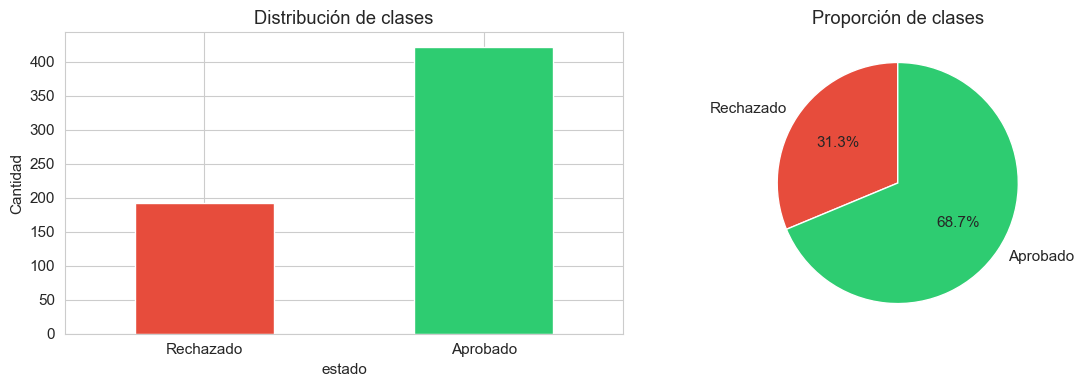

In [10]:
# 3.1  Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#e74c3c', '#2ecc71']          # Rechazado, Aprobado
counts = df['estado'].value_counts().reindex(CLASS_NAMES)

counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Cantidad')
axes[0].set_xticklabels(CLASS_NAMES, rotation=0)

counts.plot(kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_ylabel('')
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

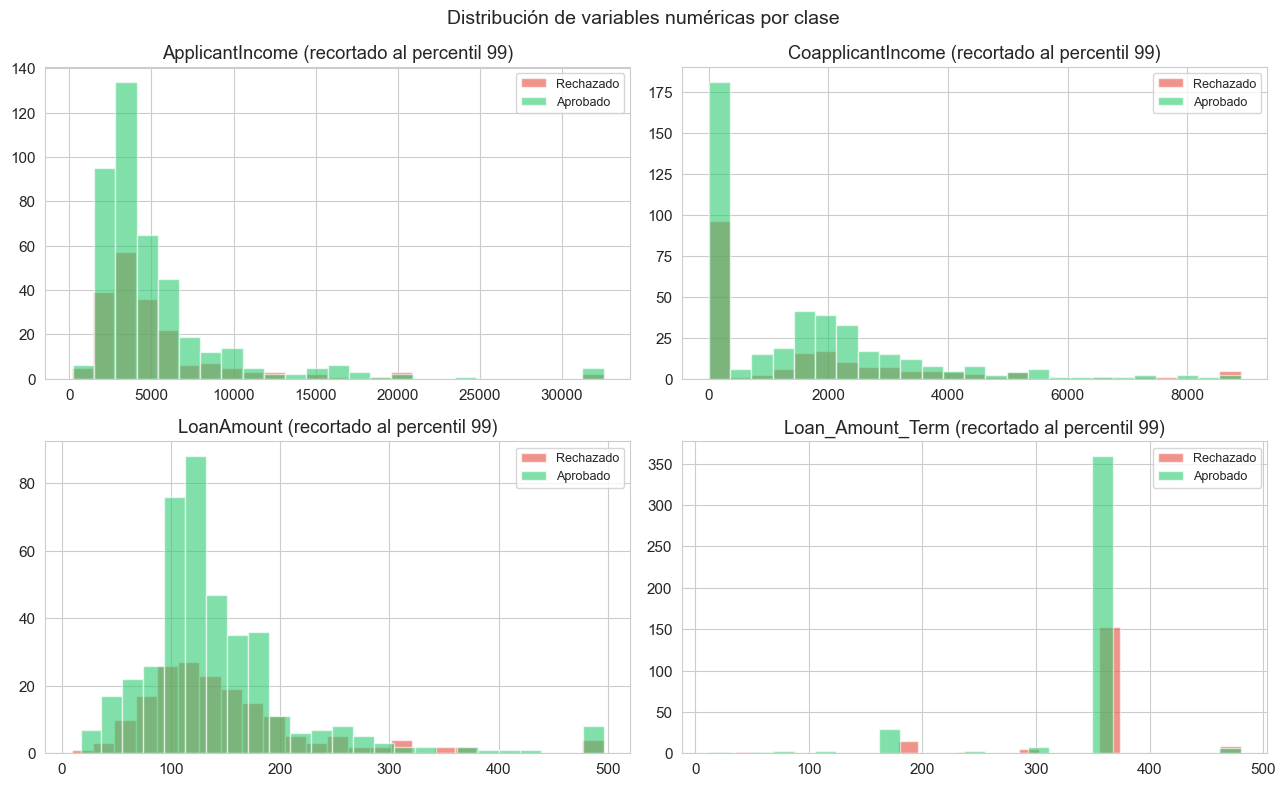

In [11]:
# 3.2  Distribución de las variables numéricas por clase
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat in zip(axes.ravel(), num_cols):
    upper = df[feat].quantile(0.99)       # se recorta el 1 % superior para ver mejor la forma
    for label, color in zip([0, 1], colors):
        subset = df.loc[df['target'] == label, feat].dropna().clip(upper=upper)
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=CLASS_NAMES[label])
    ax.set_title(f'{feat} (recortado al percentil 99)')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de variables numéricas por clase', fontsize=14)
plt.tight_layout()
plt.show()

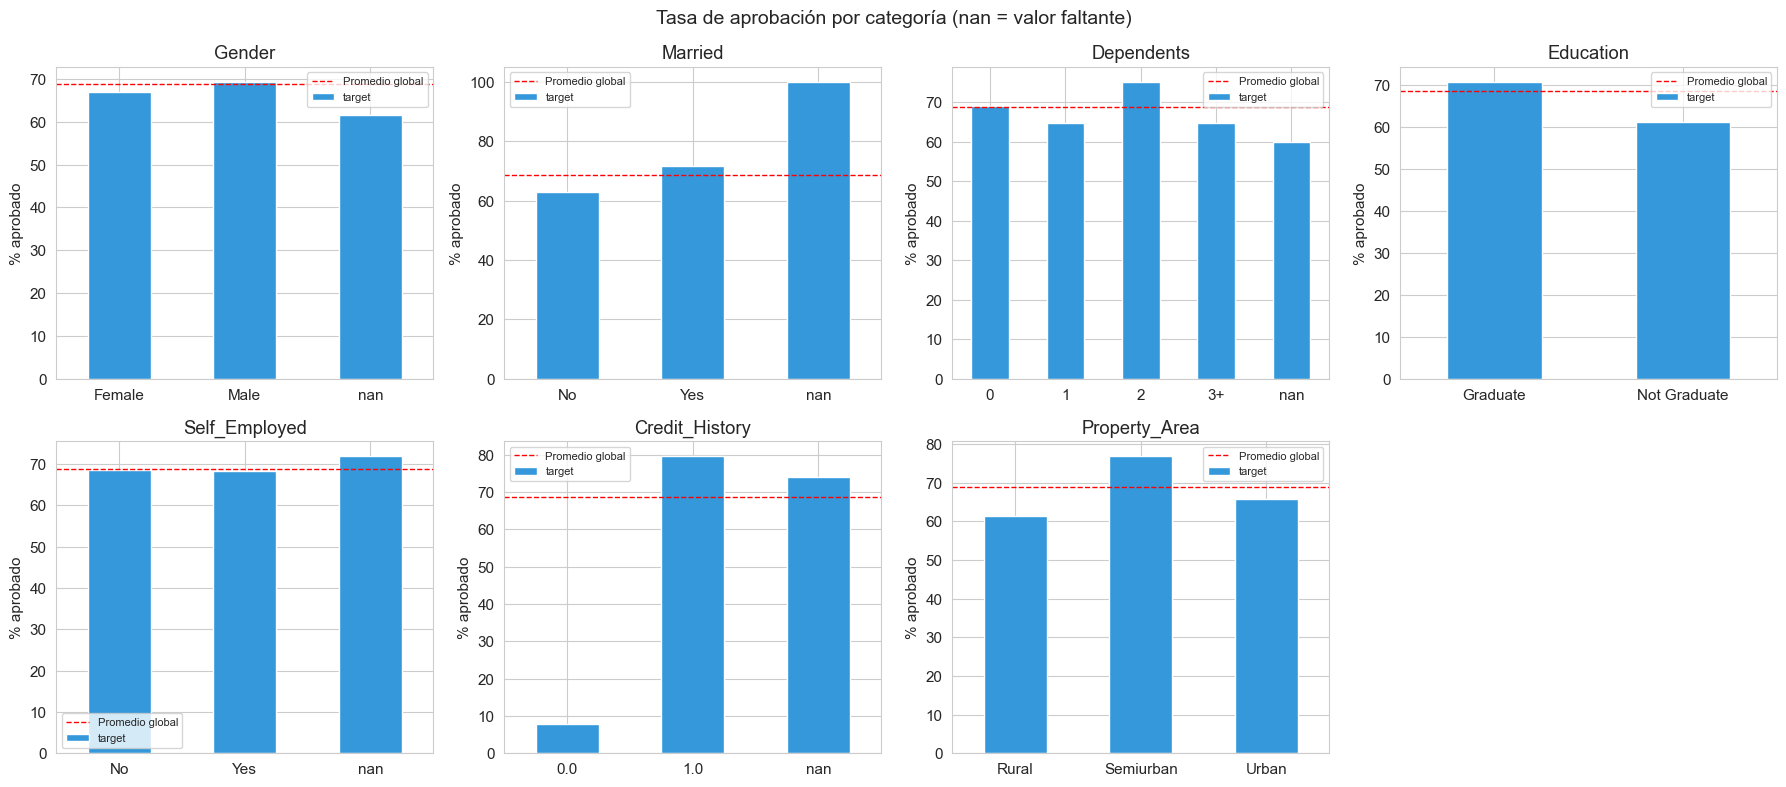

In [12]:
# 3.3  Tasa de aprobación por variable categórica
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col, dropna=False)['target'].mean() * 100
    rate.index = rate.index.astype(str)
    rate.plot(kind='bar', ax=ax, color='#3498db')
    ax.axhline(df['target'].mean() * 100, color='red', linestyle='--', linewidth=1,
               label='Promedio global')
    ax.set_title(col)
    ax.set_ylabel('% aprobado')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=8)
axes.ravel()[-1].axis('off')

plt.suptitle('Tasa de aprobación por categoría (nan = valor faltante)', fontsize=14)
plt.tight_layout()
plt.show()

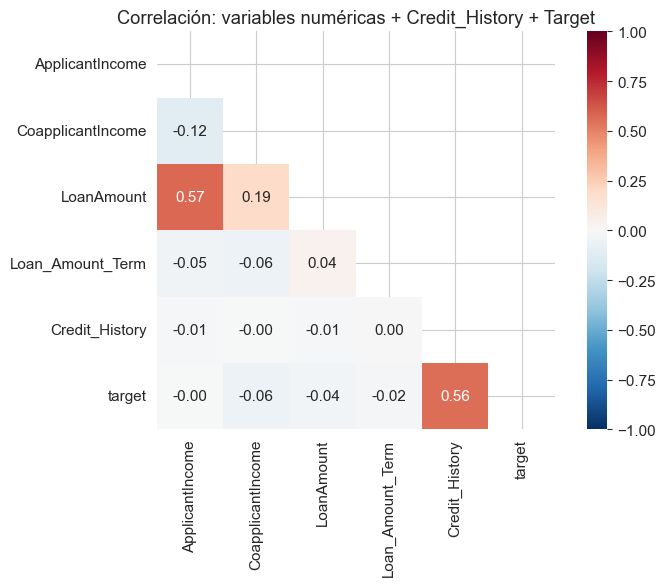

In [13]:
# 3.4  Matriz de correlación (numéricas + Credit_History + target)
corr = df[num_cols + ['Credit_History', 'target']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True)
plt.title('Correlación: variables numéricas + Credit_History + Target')
plt.tight_layout()
plt.show()

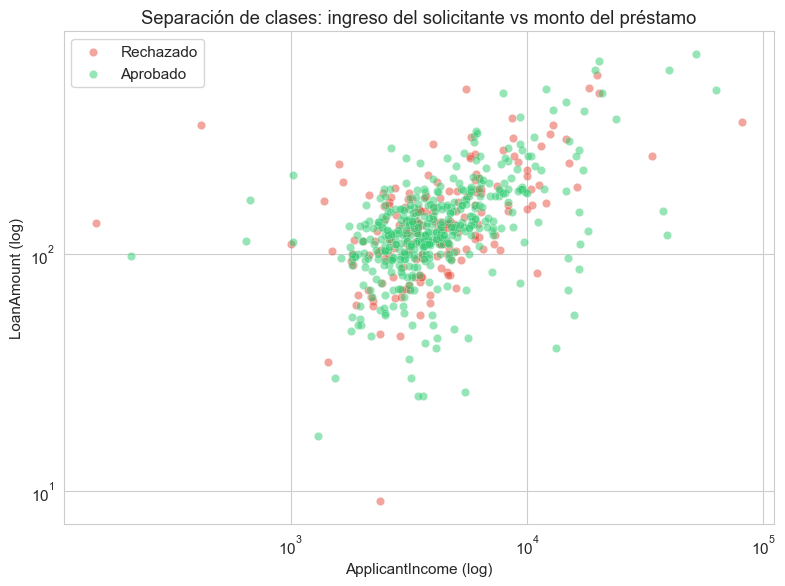

In [14]:
# 3.5  Scatter plot: ingreso del solicitante vs monto del préstamo (escala log)
fig, ax = plt.subplots(figsize=(8, 6))
for label, color, name in zip([0, 1], colors, CLASS_NAMES):
    m = df['target'] == label
    ax.scatter(df.loc[m, 'ApplicantIncome'], df.loc[m, 'LoanAmount'],
               alpha=0.5, c=color, label=name, edgecolors='w', linewidth=0.3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('ApplicantIncome (log)')
ax.set_ylabel('LoanAmount (log)')
ax.set_title('Separación de clases: ingreso del solicitante vs monto del préstamo')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [15]:
X = df[num_cols + cat_cols].copy()
y = df['target'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Test:          {X_test.shape[0]} muestras')
print(f'\nProporción en train: {y_train.mean():.1%} aprobado')
print(f'Proporción en test:  {y_test.mean():.1%} aprobado')

# Stratified K-Fold para validación cruzada
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def make_prep():
    # Devuelve un preprocesador nuevo (sin ajustar) para cada Pipeline
    num_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('sc', StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([('num', num_pipe, num_cols),
                              ('cat', cat_pipe, cat_cols)])


def get_feature_names(pipe):
    # Nombres de las columnas después del preprocesamiento
    names = pipe.named_steps['prep'].get_feature_names_out()
    return [n.split('__', 1)[1] for n in names]

Entrenamiento: 491 muestras
Test:          123 muestras

Proporción en train: 68.6% aprobado
Proporción en test:  69.1% aprobado


### Funciones auxiliares para evaluación de clasificadores

In [16]:
SCORING = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'recall': 'recall',
    'recall_rech': make_scorer(recall_score, pos_label=0)
}


def cv_summary(cv, title):
    print(f'{title} — CV 5-fold')
    if 'train_accuracy' in cv:
        print(f'  Train Accuracy:     {cv["train_accuracy"].mean():.4f}')
    print(f'  Accuracy:           {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1-Score:           {cv["test_f1"].mean():.4f} ± {cv["test_f1"].std():.4f}')
    print(f'  Recall (Aprobado):  {cv["test_recall"].mean():.4f} ± {cv["test_recall"].std():.4f}')
    print(f'  Recall (Rechazado): {cv["test_recall_rech"].mean():.4f} ± {cv["test_recall_rech"].std():.4f}')


def get_scores(model, X_te):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X_te)[:, 1]
    return model.decision_function(X_te)


def test_metrics(model, X_te, y_te):
    # Métricas en el conjunto de test (sin gráficos)
    y_pred = model.predict(X_te)
    return {
        'Accuracy':           accuracy_score(y_te, y_pred),
        'Precision':          precision_score(y_te, y_pred, zero_division=0),
        'Recall':             recall_score(y_te, y_pred),
        'F1-Score':           f1_score(y_te, y_pred),
        'Recall (Rechazado)': recall_score(y_te, y_pred, pos_label=0),
        'AUC':                roc_auc_score(y_te, get_scores(model, X_te))
    }


def eval_classifier(model, X_tr, y_tr, X_te, y_te, model_name='Modelo'):
    # Evalúa un clasificador: métricas, matriz de confusión y reporte
    y_pred = model.predict(X_te)
    metrics = test_metrics(model, X_te, y_te)

    print(f'=== {model_name} ===')
    for k, v in metrics.items():
        print(f'  {k}: {v:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    cm = confusion_matrix(y_te, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    axes[0].set_title(f'Matriz de Confusión — {model_name}')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    # Desglose de aciertos y errores (filas = real, columnas = predicción)
    labels = ['Rechazado\ncorrecto', 'Aprobado\nindebido\n(riesgo)',
              'Rechazado\nindebido', 'Aprobado\ncorrecto']
    values = [cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]]
    bar_colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']
    axes[1].bar(labels, values, color=bar_colors)
    axes[1].set_title(f'Desglose — {model_name}')
    axes[1].set_ylabel('Cantidad')

    plt.tight_layout()
    plt.show()

    print(f'\n  Aprobado indebido (real Rechazado → predicho Aprobado): {cm[0, 1]}')
    print(f'  Rechazado indebido (real Aprobado → predicho Rechazado): {cm[1, 0]}')
    print(f'\nReporte completo:')
    print(classification_report(y_te, y_pred, target_names=CLASS_NAMES))

    return metrics


def plot_roc(model, X_te, y_te, model_name='Modelo', ax=None):
    # Genera la curva ROC de un modelo
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    if not (hasattr(model, 'predict_proba') or hasattr(model, 'decision_function')):
        print(f'{model_name}: no soporta probabilidades')
        return None

    y_score = get_scores(model, X_te)
    fpr, tpr, _ = roc_curve(y_te, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
    ax.set_title(f'Curva ROC — {model_name}')
    ax.legend()

    return roc_auc


# ══ EJERCICIO 1 · función de apoyo run_grid (se usa en 5.5, 6.7, 7.5 y 8.5) ══
grids = {}            # GridSearchCV ajustado por modelo
tuned_metrics = {}    # métricas en test de cada modelo optimizado


def run_grid(name, pipe, param_grid):
    # GridSearchCV(cv=5, scoring='f1') + evaluación del mejor modelo en test
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    grids[name] = grid
    tuned_metrics[name] = test_metrics(grid.best_estimator_, X_test, y_test)

    print(f'{name} — mejores parámetros: {grid.best_params_}')
    print(f'  F1 (CV 5-fold): {grid.best_score_:.4f}')
    print(f'  Test → ' + ', '.join(f'{k}: {v:.4f}' for k, v in tuned_metrics[name].items()))

    res = pd.DataFrame(grid.cv_results_)
    cols = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
    return res[cols].sort_values('rank_test_score').head(5).reset_index(drop=True)


# ══ EJERCICIO 2 · función de apoyo balance_report (se usa en 5.6, 6.8 y 7.6) ══
balance_results = {}   # {modelo: {'Base': métricas, 'class_weight': métricas, 'SMOTE': métricas}}


def balance_report(name, base_metrics, bal_model):
    # Compara el modelo base contra su versión con class_weight='balanced'
    m = test_metrics(bal_model, X_test, y_test)
    balance_results.setdefault(name, {})['Base'] = base_metrics
    balance_results[name]['class_weight'] = m
    comp = pd.DataFrame({'Sin balanceo': base_metrics,
                         'class_weight="balanced"': m}).T
    return comp[['Recall (Rechazado)', 'Precision', 'Recall', 'F1-Score', 'Accuracy']].round(4)

---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima P(y=1|x) mediante la función sigmoide σ(z) = 1/(1+e^(−z)). La frontera de decisión es lineal en el espacio de features. Se optimiza minimizando la Log-Loss (entropía cruzada binaria) con regularización L2 por defecto.

In [19]:
# 5.1  Pipeline con preprocesamiento
pipe_lr = Pipeline([
    ('prep', make_prep()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Validación cruzada estratificada
cv_lr = cross_validate(pipe_lr, X_train, y_train, cv=skf,
                       scoring=SCORING, return_train_score=True)
cv_summary(cv_lr, 'Regresión Logística')

# Entrenar modelo final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Regresión Logística — CV 5-fold
  Train Accuracy:     0.7979
  Accuracy:           0.7922 ± 0.0444
  F1-Score:           0.8658 ± 0.0263
  Recall (Aprobado):  0.9734 ± 0.0217
  Recall (Rechazado): 0.3961 ± 0.1125


=== Regresión Logística ===
  Accuracy: 0.8537
  Precision: 0.8317
  Recall: 0.9882
  F1-Score: 0.9032
  Recall (Rechazado): 0.5526
  AUC: 0.8666


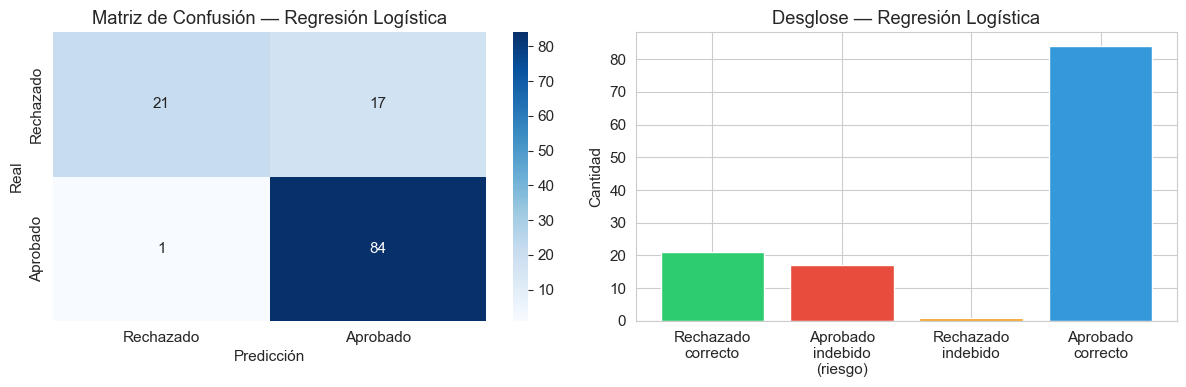


  Aprobado indebido (real Rechazado → predicho Aprobado): 17
  Rechazado indebido (real Aprobado → predicho Rechazado): 1

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.95      0.55      0.70        38
    Aprobado       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [20]:
# 5.2  Evaluación completa
metrics_lr = eval_classifier(pipe_lr, X_train, y_train, X_test, y_test,
                             'Regresión Logística')

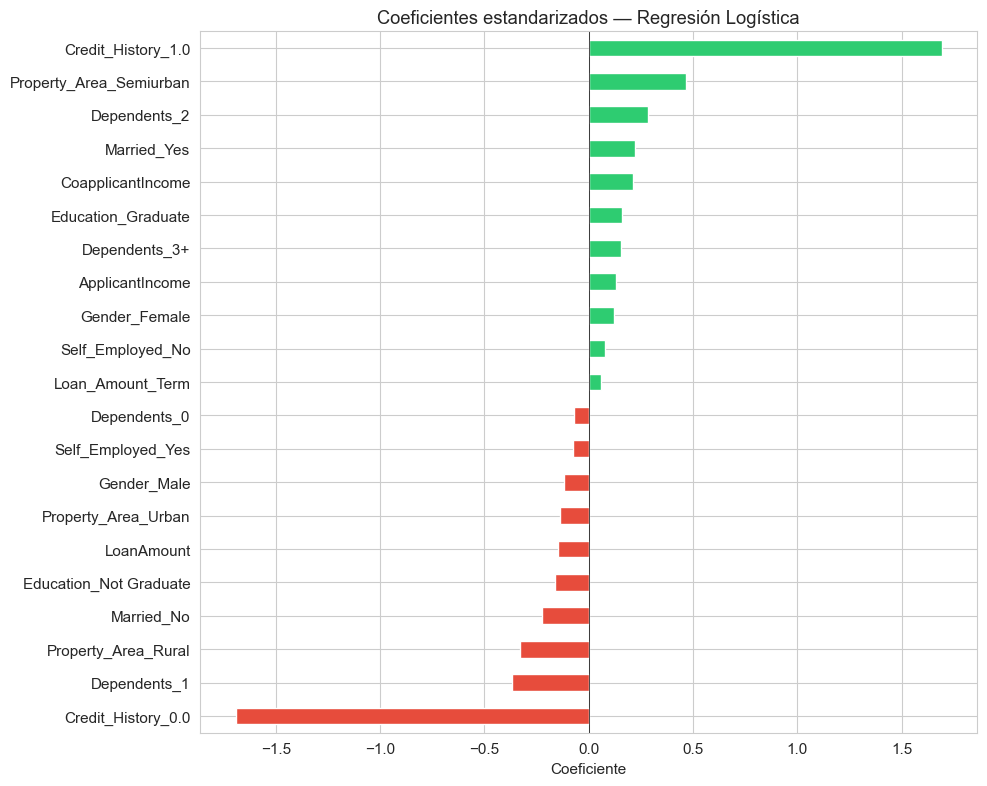

Interpretación:
  → Features que más indican RECHAZADO: ['Credit_History_0.0', 'Dependents_1', 'Property_Area_Rural']
  → Features que más indican APROBADO:  ['Dependents_2', 'Property_Area_Semiurban', 'Credit_History_1.0']


In [21]:
# 5.3  Coeficientes estandarizados
feat_names = get_feature_names(pipe_lr)
coefs = pd.Series(pipe_lr.named_steps['clf'].coef_[0], index=feat_names).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors_bar = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs]
coefs.plot(kind='barh', ax=ax, color=colors_bar)
ax.set_title('Coeficientes estandarizados — Regresión Logística')
ax.set_xlabel('Coeficiente')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print('Interpretación:')
print(f'  → Features que más indican RECHAZADO: {coefs.head(3).index.tolist()}')
print(f'  → Features que más indican APROBADO:  {coefs.tail(3).index.tolist()}')

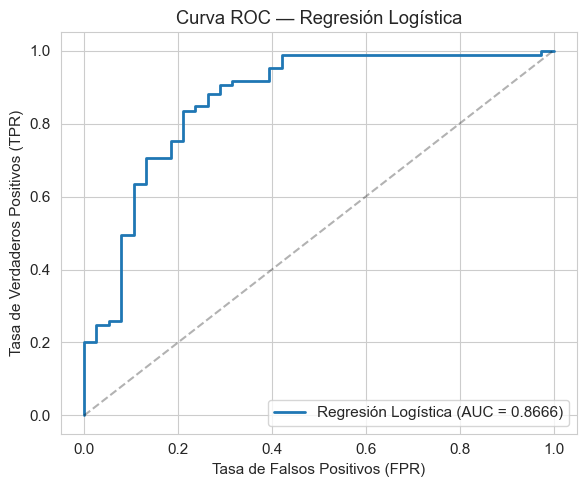

AUC: 0.8666


In [22]:
# 5.4  Curva ROC
fig, ax = plt.subplots(figsize=(6, 5))
auc_lr = plot_roc(pipe_lr, X_test, y_test, 'Regresión Logística', ax)
plt.tight_layout()
plt.show()
print(f'AUC: {auc_lr:.4f}')

### 5.5  Ejercicio 1 — GridSearchCV para Regresión Logística
Parámetro sugerido: `C = [0.01, 0.1, 1, 10, 100]`.

In [23]:
# 5.5  GridSearchCV — Regresión Logística
run_grid('Regresión Logística',
         Pipeline([('prep', make_prep()),
                   ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
         {'clf__C': [0.01, 0.1, 1, 10, 100]})

Regresión Logística — mejores parámetros: {'clf__C': 0.1}
  F1 (CV 5-fold): 0.8699
  Test → Accuracy: 0.8537, Precision: 0.8317, Recall: 0.9882, F1-Score: 0.9032, Recall (Rechazado): 0.5526, AUC: 0.8638


,params,mean_test_score,std_test_score,rank_test_score
0,{'clf__C': 0.1},0.869946,0.006951,1
1,{'clf__C': 1},0.868091,0.005257,2
2,{'clf__C': 10},0.868091,0.005257,2
3,{'clf__C': 100},0.868091,0.005257,2
4,{'clf__C': 0.01},0.814002,0.002778,5


### 5.6  Ejercicio 2 — `class_weight='balanced'` en Regresión Logística

In [24]:
# ══ EJERCICIO 2 · class_weight / SMOTE ══════════════════════════════
# 5.6  Regresión Logística con class_weight='balanced'
lr_bal = Pipeline([
    ('prep', make_prep()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])
lr_bal.fit(X_train, y_train)

balance_report('Regresión Logística', metrics_lr, lr_bal)

,Recall (Rechazado),Precision,Recall,F1-Score,Accuracy
Sin balanceo,0.5526,0.8317,0.9882,0.9032,0.8537
"class_weight=""balanced""",0.7368,0.8824,0.8824,0.8824,0.8374


---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** CART construye particiones recursivas del espacio de features. En cada nodo selecciona la feature y el umbral que maximizan la reducción de impureza (Gini: G(t) = 1 − Σpₖ²). Las particiones son ortogonales a los ejes.

In [25]:
# 6.1  Árbol sin restricciones (para mostrar sobreajuste)
pipe_dt_full = Pipeline([
    ('prep', make_prep()),
    ('clf', DecisionTreeClassifier(random_state=42))
])

cv_dt_full = cross_validate(pipe_dt_full, X_train, y_train, cv=skf,
                            scoring=SCORING, return_train_score=True)
cv_summary(cv_dt_full, 'Árbol de Decisión (SIN restricciones)')
print(f'\n⚠ Train accuracy ~1.0 indica sobreajuste')

Árbol de Decisión (SIN restricciones) — CV 5-fold
  Train Accuracy:     1.0000
  Accuracy:           0.6944 ± 0.0257
  F1-Score:           0.7790 ± 0.0215
  Recall (Aprobado):  0.7865 ± 0.0437
  Recall (Rechazado): 0.4935 ± 0.0747

⚠ Train accuracy ~1.0 indica sobreajuste


In [26]:
# 6.2  Árbol con pre-poda
pipe_dt = Pipeline([
    ('prep', make_prep()),
    ('clf', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=skf,
                       scoring=SCORING, return_train_score=True)
cv_summary(cv_dt, 'Árbol de Decisión (con pre-poda)')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Árbol de Decisión (con pre-poda) — CV 5-fold
  Train Accuracy:     0.8187
  Accuracy:           0.7474 ± 0.0377
  F1-Score:           0.8317 ± 0.0264
  Recall (Aprobado):  0.9112 ± 0.0453
  Recall (Rechazado): 0.3899 ± 0.0777


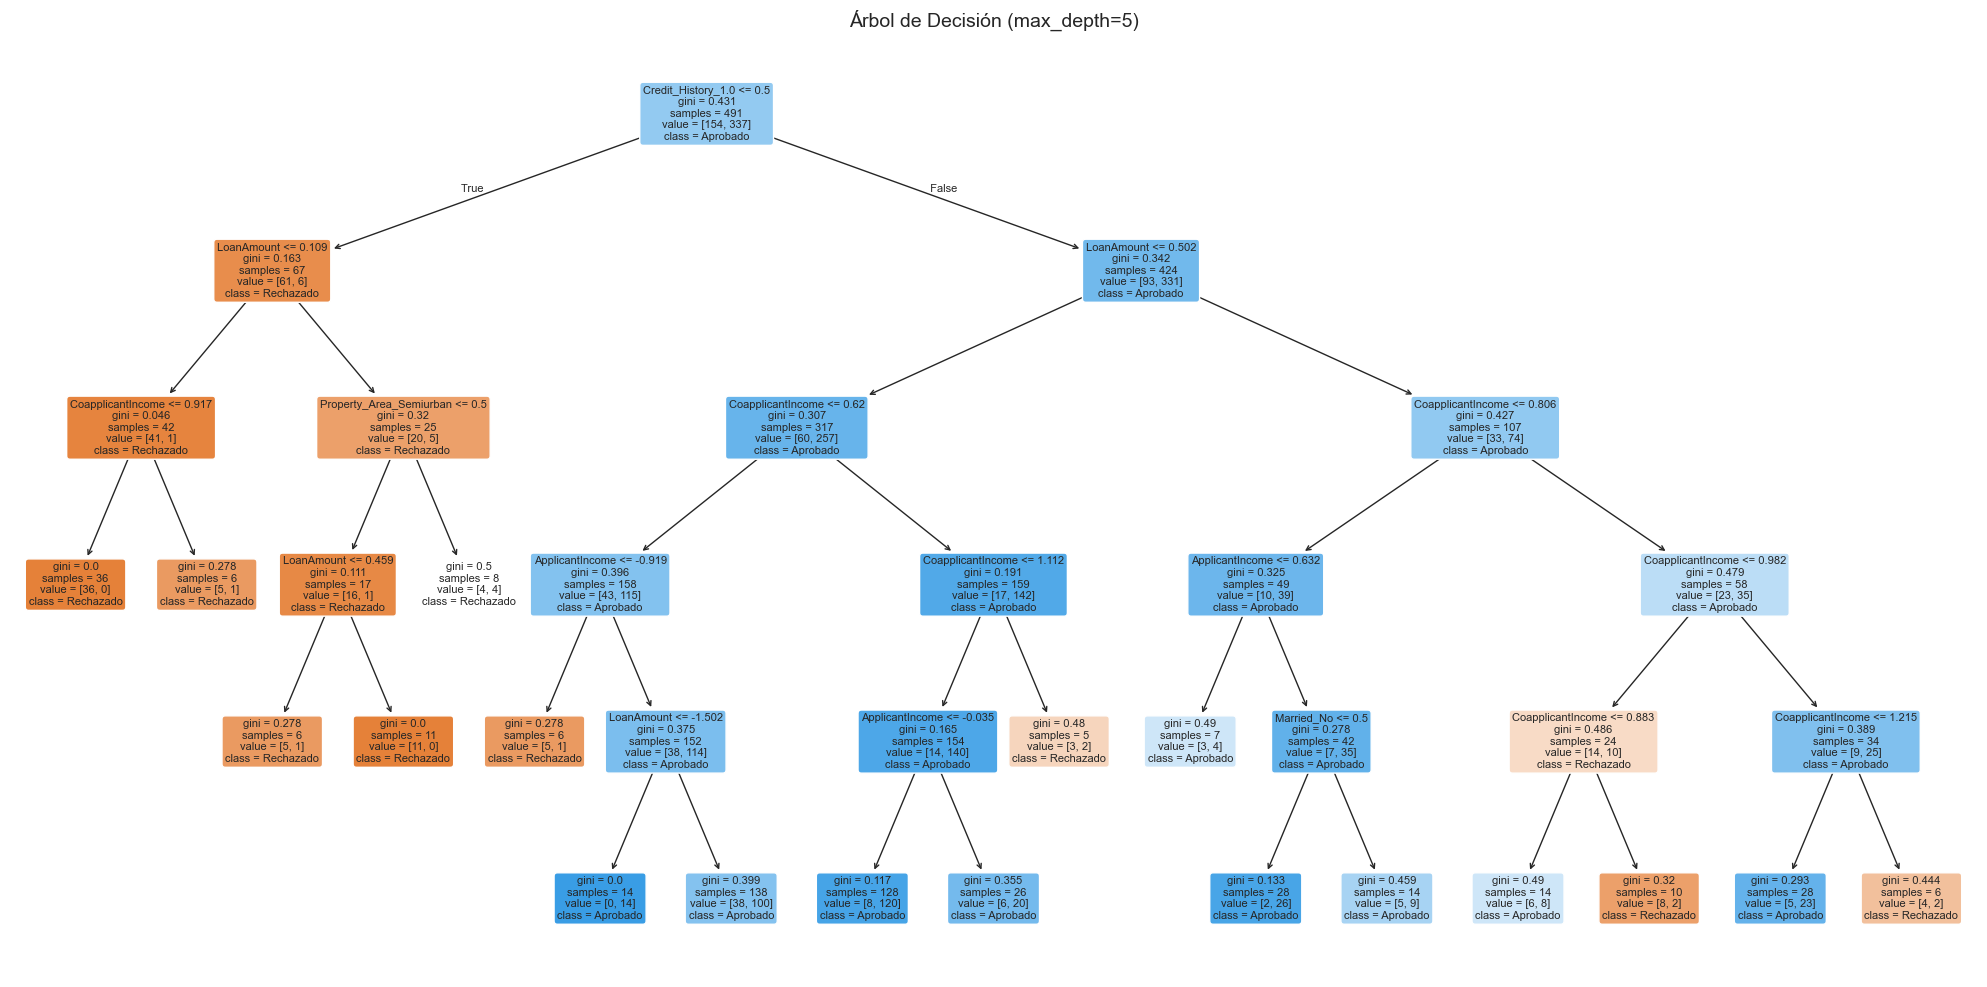

In [27]:
# 6.3  Visualización del árbol podado
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(pipe_dt.named_steps['clf'],
          feature_names=get_feature_names(pipe_dt),
          class_names=CLASS_NAMES,
          filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title('Árbol de Decisión (max_depth=5)', fontsize=14)
plt.tight_layout()
plt.show()

=== Árbol de Decisión ===
  Accuracy: 0.8211
  Precision: 0.8462
  Recall: 0.9059
  F1-Score: 0.8750
  Recall (Rechazado): 0.6316
  AUC: 0.8025


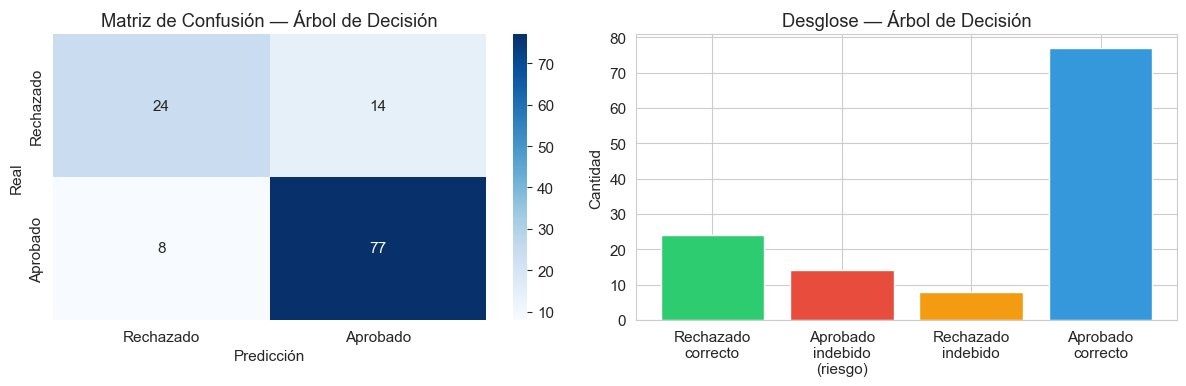


  Aprobado indebido (real Rechazado → predicho Aprobado): 14
  Rechazado indebido (real Aprobado → predicho Rechazado): 8

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.75      0.63      0.69        38
    Aprobado       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82      0.82      0.82       123



In [28]:
# 6.4  Evaluación completa
metrics_dt = eval_classifier(pipe_dt, X_train, y_train, X_test, y_test,
                             'Árbol de Decisión')

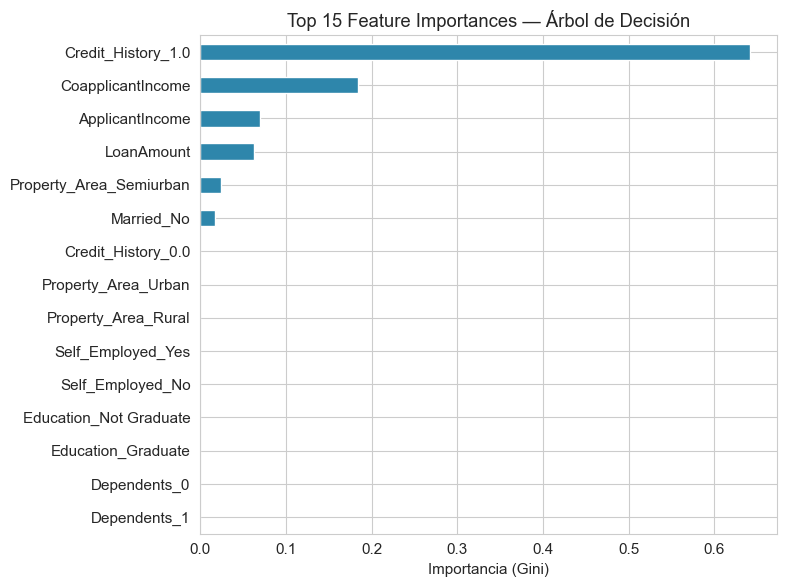

In [29]:
# 6.5  Importancia de features
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=get_feature_names(pipe_dt)
).sort_values(ascending=True)

top_imp = importances.tail(15)
fig, ax = plt.subplots(figsize=(8, 6))
top_imp.plot(kind='barh', ax=ax, color='#2E86AB')
ax.set_title('Top 15 Feature Importances — Árbol de Decisión')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

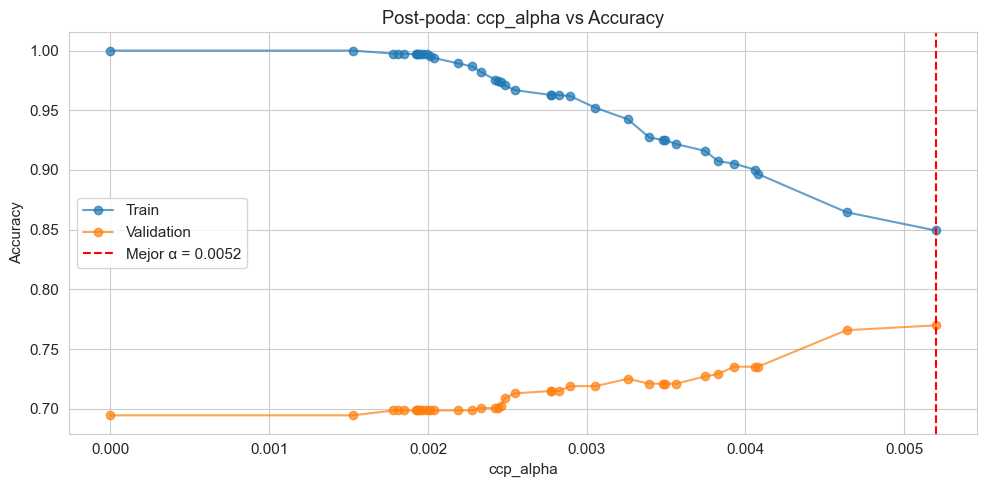

Mejor ccp_alpha: 0.005198


In [30]:
# 6.6  Post-poda con ccp_alpha
# El camino de poda se calcula sobre los datos de entrenamiento ya preprocesados
X_train_prep = make_prep().fit_transform(X_train)
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train_prep, y_train)
alphas = np.unique(path.ccp_alphas[:-1])   # excluir el último (árbol trivial)

train_scores, test_scores = [], []
for alpha in alphas:
    dt_temp = Pipeline([('prep', make_prep()),
                        ('clf', DecisionTreeClassifier(ccp_alpha=alpha, random_state=42))])
    cv_temp = cross_validate(dt_temp, X_train, y_train, cv=skf,
                             scoring='accuracy', return_train_score=True)
    train_scores.append(cv_temp['train_score'].mean())
    test_scores.append(cv_temp['test_score'].mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas, train_scores, 'o-', label='Train', alpha=0.7)
ax.plot(alphas, test_scores, 'o-', label='Validation', alpha=0.7)
best_idx = np.argmax(test_scores)
ax.axvline(x=alphas[best_idx], color='red', linestyle='--',
           label=f'Mejor α = {alphas[best_idx]:.4f}')
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Accuracy')
ax.set_title('Post-poda: ccp_alpha vs Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Mejor ccp_alpha: {alphas[best_idx]:.6f}')

### 6.7  Ejercicio 1 — GridSearchCV para el Árbol de Decisión
Parámetros sugeridos: `max_depth = [3, 5, 7, 10, None]`, `min_samples_leaf = [1, 5, 10]`.

In [31]:
# 6.7  GridSearchCV — Árbol de Decisión
run_grid('Árbol de Decisión',
         Pipeline([('prep', make_prep()),
                   ('clf', DecisionTreeClassifier(random_state=42))]),
         {'clf__max_depth': [3, 5, 7, 10, None],
          'clf__min_samples_leaf': [1, 5, 10]})

Árbol de Decisión — mejores parámetros: {'clf__max_depth': 3, 'clf__min_samples_leaf': 1}
  F1 (CV 5-fold): 0.8636
  Test → Accuracy: 0.8455, Precision: 0.8235, Recall: 0.9882, F1-Score: 0.8984, Recall (Rechazado): 0.5263, AUC: 0.7375


,params,mean_test_score,std_test_score,rank_test_score
0,"{'clf__max_depth': 3, 'clf__min_samples_leaf': 1}",0.863617,0.005757,1
1,"{'clf__max_depth': 3, 'clf__min_samples_leaf':...",0.862703,0.007437,2
2,"{'clf__max_depth': 3, 'clf__min_samples_leaf': 5}",0.859468,0.014958,3
3,"{'clf__max_depth': 5, 'clf__min_samples_leaf': 1}",0.841981,0.025243,4
4,"{'clf__max_depth': 5, 'clf__min_samples_leaf': 5}",0.838376,0.022885,5


### 6.8  Ejercicio 2 — `class_weight='balanced'` en el Árbol de Decisión

In [32]:
# ══ EJERCICIO 2 · class_weight / SMOTE ══════════════════════════════
# 6.8  Árbol con class_weight='balanced' (misma pre-poda que el modelo base)
dt_bal = Pipeline([
    ('prep', make_prep()),
    ('clf', DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5,
                                   class_weight='balanced', random_state=42))
])
dt_bal.fit(X_train, y_train)

balance_report('Árbol de Decisión', metrics_dt, dt_bal)

,Recall (Rechazado),Precision,Recall,F1-Score,Accuracy
Sin balanceo,0.6316,0.8462,0.9059,0.8750,0.8211
"class_weight=""balanced""",0.6053,0.8295,0.8588,0.8439,0.7805


---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** SVM busca el hiperplano de máximo margen γ = 2/‖w‖ que separa las clases. Con margen suave, permite violaciones controladas: min ½‖w‖² + C·Σξᵢ. El kernel trick transforma el espacio para manejar no linealidad.

In [33]:
# 7.1  Pipeline SVM con kernel RBF
pipe_svm = Pipeline([
    ('prep', make_prep()),
    ('clf', SVC(kernel='rbf', C=1.0, probability=True, random_state=42))
])

cv_svm = cross_validate(pipe_svm, X_train, y_train, cv=skf,
                        scoring=SCORING, return_train_score=True)
cv_summary(cv_svm, 'SVM (RBF, C=1.0)')

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

SVM (RBF, C=1.0) — CV 5-fold
  Train Accuracy:     0.8111
  Accuracy:           0.7963 ± 0.0435
  F1-Score:           0.8691 ± 0.0258
  Recall (Aprobado):  0.9822 ± 0.0174
  Recall (Rechazado): 0.3897 ± 0.1061


=== SVM (RBF) ===
  Accuracy: 0.8537
  Precision: 0.8317
  Recall: 0.9882
  F1-Score: 0.9032
  Recall (Rechazado): 0.5526
  AUC: 0.8139


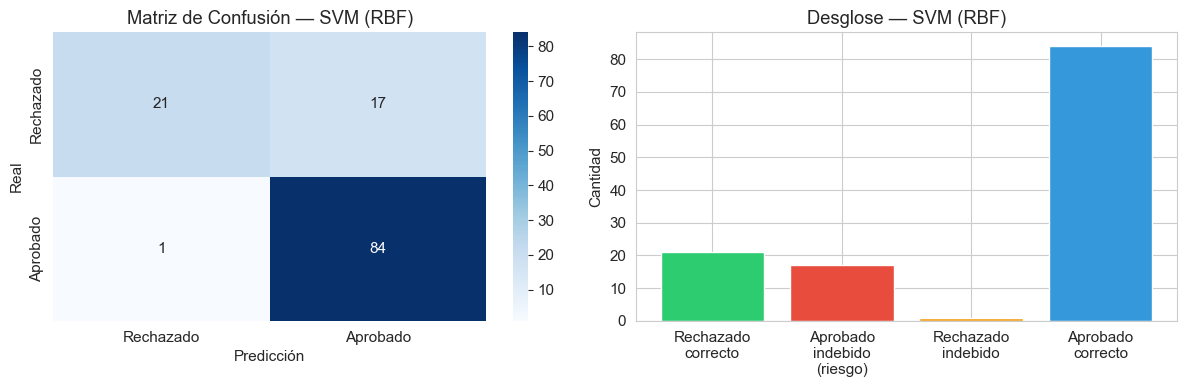


  Aprobado indebido (real Rechazado → predicho Aprobado): 17
  Rechazado indebido (real Aprobado → predicho Rechazado): 1

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.95      0.55      0.70        38
    Aprobado       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [34]:
# 7.2  Evaluación completa
metrics_svm = eval_classifier(pipe_svm, X_train, y_train, X_test, y_test, 'SVM (RBF)')

  Kernel linear  : Accuracy = 0.7983
  Kernel rbf     : Accuracy = 0.7963
  Kernel poly    : Accuracy = 0.7860


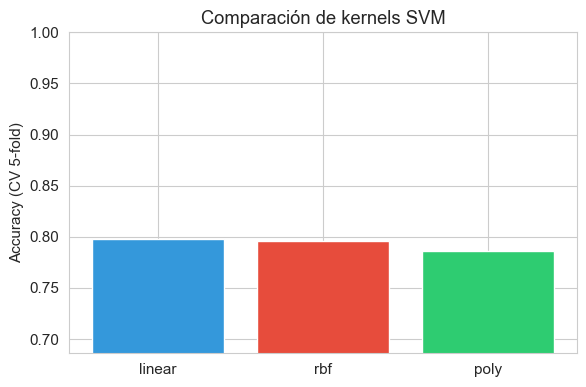

In [37]:
# 7.3  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
kernel_results = {}

for k in kernels:
    pipe_k = Pipeline([
        ('prep', make_prep()),
        ('clf', SVC(kernel=k, C=1.0, probability=True, random_state=42))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf, scoring='accuracy')
    kernel_results[k] = cv_k['test_score'].mean()
    print(f'  Kernel {k:8s}: Accuracy = {kernel_results[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(kernel_results.keys(), kernel_results.values(), color=['#3498db', '#e74c3c', '#2ecc71'])
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Comparación de kernels SVM')
ax.set_ylim(max(0, min(kernel_results.values()) - 0.1), 1.0)
plt.tight_layout()
plt.show()

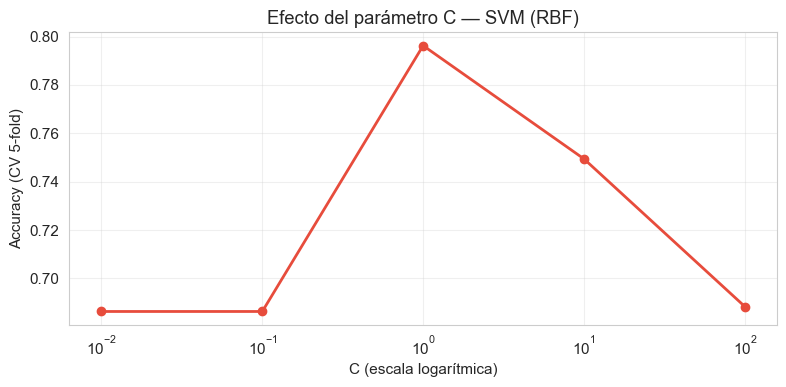


Interpretación:
  C bajo → margen amplio, más errores permitidos (mayor sesgo)
  C alto → margen estrecho, menos errores permitidos (mayor varianza)


In [38]:
# 7.4  Efecto del parámetro C
C_values = [0.01, 0.1, 1, 10, 100]
c_scores = []

for c in C_values:
    pipe_c = Pipeline([
        ('prep', make_prep()),
        ('clf', SVC(kernel='rbf', C=c, random_state=42))
    ])
    cv_c = cross_validate(pipe_c, X_train, y_train, cv=skf, scoring='accuracy')
    c_scores.append(cv_c['test_score'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(C_values, c_scores, 'o-', color='#e74c3c', linewidth=2)
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('Accuracy (CV 5-fold)')
ax.set_title('Efecto del parámetro C — SVM (RBF)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nInterpretación:')
print('  C bajo → margen amplio, más errores permitidos (mayor sesgo)')
print('  C alto → margen estrecho, menos errores permitidos (mayor varianza)')

### 7.5  Ejercicio 1 — GridSearchCV para SVM
Parámetros sugeridos: `C = [0.1, 1, 10]`, `gamma = [0.001, 0.01, 0.1]` (kernel RBF).

In [40]:
# 7.5  GridSearchCV — SVM
run_grid('SVM (RBF)',
         Pipeline([('prep', make_prep()),
                   ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
         {'clf__C': [0.1, 1, 10],
          'clf__gamma': [0.001, 0.01, 0.1]})

SVM (RBF) — mejores parámetros: {'clf__C': 1, 'clf__gamma': 0.01}
  F1 (CV 5-fold): 0.8699
  Test → Accuracy: 0.8537, Precision: 0.8317, Recall: 0.9882, F1-Score: 0.9032, Recall (Rechazado): 0.5526, AUC: 0.8211


,params,mean_test_score,std_test_score,rank_test_score
0,"{'clf__C': 10, 'clf__gamma': 0.001}",0.869946,0.006951,1
1,"{'clf__C': 1, 'clf__gamma': 0.01}",0.869946,0.006951,1
2,"{'clf__C': 1, 'clf__gamma': 0.1}",0.867331,0.006705,3
3,"{'clf__C': 10, 'clf__gamma': 0.01}",0.865449,0.008740,4
4,"{'clf__C': 10, 'clf__gamma': 0.1}",0.830972,0.016713,5


### 7.6  Ejercicio 2 — `class_weight='balanced'` en SVM

In [41]:
# ══ EJERCICIO 2 · class_weight / SMOTE ══════════════════════════════
# 7.6  SVM con class_weight='balanced'
svm_bal = Pipeline([
    ('prep', make_prep()),
    ('clf', SVC(kernel='rbf', C=1.0, class_weight='balanced',
                probability=True, random_state=42))
])
svm_bal.fit(X_train, y_train)

balance_report('SVM (RBF)', metrics_svm, svm_bal)

,Recall (Rechazado),Precision,Recall,F1-Score,Accuracy
Sin balanceo,0.5526,0.8317,0.9882,0.9032,0.8537
"class_weight=""balanced""",0.6316,0.8526,0.9529,0.9000,0.8537


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Algoritmo de aprendizaje basado en instancias (lazy learning). No construye un modelo explícito; clasifica por voto mayoritario de los K vecinos más cercanos según distancia Euclidiana (por defecto). La regla empírica sugiere K ≈ √n.

In [42]:
# 8.1  Pipeline KNN
pipe_knn = Pipeline([
    ('prep', make_prep()),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=skf,
                        scoring=SCORING, return_train_score=True)
cv_summary(cv_knn, 'KNN (K=5)')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=5) — CV 5-fold
  Train Accuracy:     0.7918
  Accuracy:           0.7170 ± 0.0428
  F1-Score:           0.8145 ± 0.0277
  Recall (Aprobado):  0.9054 ± 0.0438
  Recall (Rechazado): 0.3056 ± 0.1065


=== KNN (K=5) ===
  Accuracy: 0.8130
  Precision: 0.8039
  Recall: 0.9647
  F1-Score: 0.8770
  Recall (Rechazado): 0.4737
  AUC: 0.7618


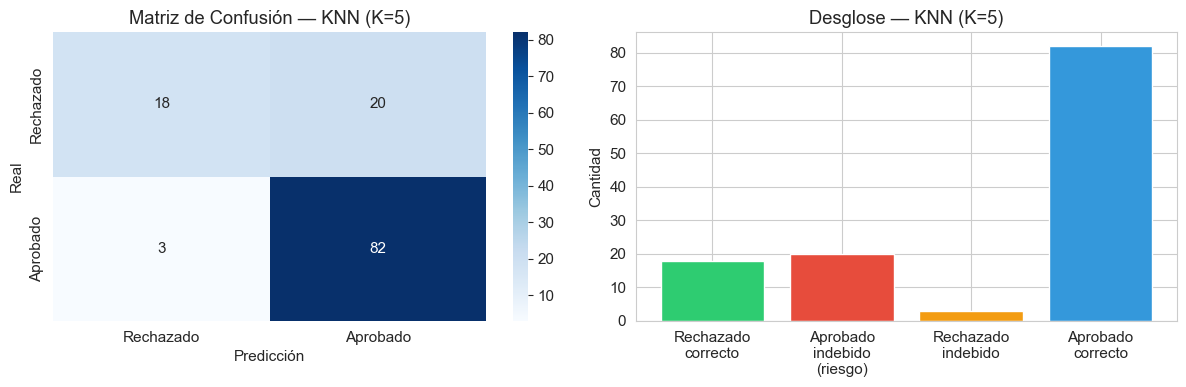


  Aprobado indebido (real Rechazado → predicho Aprobado): 20
  Rechazado indebido (real Aprobado → predicho Rechazado): 3

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.86      0.47      0.61        38
    Aprobado       0.80      0.96      0.88        85

    accuracy                           0.81       123
   macro avg       0.83      0.72      0.74       123
weighted avg       0.82      0.81      0.79       123



In [43]:
# 8.2  Evaluación completa
metrics_knn = eval_classifier(pipe_knn, X_train, y_train, X_test, y_test, 'KNN (K=5)')

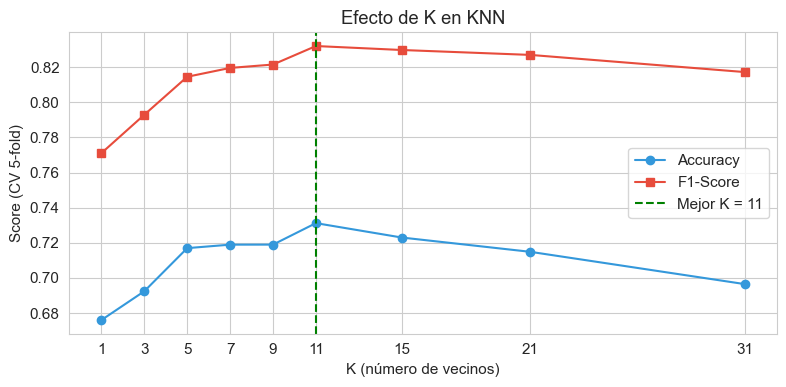

Mejor K por F1: 11
K empírico (√491): 22


In [44]:
# 8.3  Búsqueda del K óptimo
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31]
k_scores_acc = []
k_scores_f1 = []

for k in k_values:
    pipe_k = Pipeline([
        ('prep', make_prep()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    cv_k = cross_validate(pipe_k, X_train, y_train, cv=skf, scoring=['accuracy', 'f1'])
    k_scores_acc.append(cv_k['test_accuracy'].mean())
    k_scores_f1.append(cv_k['test_f1'].mean())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, k_scores_acc, 'o-', label='Accuracy', color='#3498db')
ax.plot(k_values, k_scores_f1, 's-', label='F1-Score', color='#e74c3c')
best_k = k_values[np.argmax(k_scores_f1)]
ax.axvline(x=best_k, color='green', linestyle='--', label=f'Mejor K = {best_k}')
ax.set_xlabel('K (número de vecinos)')
ax.set_ylabel('Score (CV 5-fold)')
ax.set_title('Efecto de K en KNN')
ax.legend()
ax.set_xticks(k_values)
plt.tight_layout()
plt.show()

print(f'Mejor K por F1: {best_k}')
print(f'K empírico (√{len(X_train)}): {int(np.sqrt(len(X_train)))}')

In [47]:
# 8.4  Comparación de métricas de distancia
distances = ['euclidean', 'manhattan', 'minkowski']
dist_results = {}

for d in distances:
    p_val = 3 if d == 'minkowski' else 2
    pipe_d = Pipeline([
        ('prep', make_prep()),
        ('clf', KNeighborsClassifier(n_neighbors=5, metric=d, p=p_val))
    ])
    cv_d = cross_validate(pipe_d, X_train, y_train, cv=skf, scoring='f1')
    dist_results[d] = cv_d['test_score'].mean()
    label = f'{d} (p={p_val})' if d == 'minkowski' else d
    print(f'  Distancia {label:20s}: F1 = {dist_results[d]:.4f}')

  Distancia euclidean           : F1 = 0.8145
  Distancia manhattan           : F1 = 0.8315
  Distancia minkowski (p=3)     : F1 = 0.8161


### 8.5  Ejercicio 1 — GridSearchCV para KNN
Parámetros sugeridos: `n_neighbors = [3, 5, 9, 15, 21]`, `weights = ['uniform', 'distance']`.

In [48]:
# ══ EJERCICIO 1 · GridSearchCV ══════════════════════════════════════
# 8.5  GridSearchCV — KNN
run_grid('KNN (K=5)',
         Pipeline([('prep', make_prep()),
                   ('clf', KNeighborsClassifier())]),
         {'clf__n_neighbors': [3, 5, 9, 15, 21],
          'clf__weights': ['uniform', 'distance']})

KNN (K=5) — mejores parámetros: {'clf__n_neighbors': 15, 'clf__weights': 'uniform'}
  F1 (CV 5-fold): 0.8413
  Test → Accuracy: 0.7480, Precision: 0.7411, Recall: 0.9765, F1-Score: 0.8426, Recall (Rechazado): 0.2368, AUC: 0.7729


,params,mean_test_score,std_test_score,rank_test_score
0,"{'clf__n_neighbors': 15, 'clf__weights': 'unif...",0.841342,0.011604,1
1,"{'clf__n_neighbors': 15, 'clf__weights': 'dist...",0.838771,0.010354,2
2,"{'clf__n_neighbors': 21, 'clf__weights': 'dist...",0.836071,0.010208,3
3,"{'clf__n_neighbors': 9, 'clf__weights': 'unifo...",0.834950,0.012468,4
4,"{'clf__n_neighbors': 21, 'clf__weights': 'unif...",0.828925,0.013329,5


### 8.6  Ejercicio 2 — `class_weight` en KNN

⚠ **`KNeighborsClassifier` no tiene el parámetro `class_weight`** (a diferencia de Regresión Logística, Árbol y SVM), por lo que no se puede entrenar con `class_weight='balanced'`. Para KNN el desbalance se aborda únicamente con **SMOTE** (sección 9.6). En la tabla comparativa final (9.7) la columna `class_weight` de KNN aparece como *N/A*.

In [49]:
# ══ EJERCICIO 2 · class_weight / SMOTE ══════════════════════════════
# 8.6  KNN no soporta class_weight → solo se registra el modelo base
balance_results.setdefault('KNN (K=5)', {})['Base'] = metrics_knn
print('KNN no admite class_weight; se evaluará con SMOTE en la sección 9.6')

KNN no admite class_weight; se evaluará con SMOTE en la sección 9.6


---
## 9. Comparación final de modelos

In [50]:
# 9.1  Tabla resumen de métricas (modelos base, test set)
all_models = {
    'Regresión Logística': pipe_lr,
    'Árbol de Decisión': pipe_dt,
    'SVM (RBF)': pipe_svm,
    'KNN (K=5)': pipe_knn
}

all_metrics = {name: test_metrics(model, X_test, y_test) for name, model in all_models.items()}

metrics_df = pd.DataFrame(all_metrics).T.round(4)
print('=== Tabla comparativa de métricas (Test Set) ===')
metrics_df

=== Tabla comparativa de métricas (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,Recall (Rechazado),AUC
Regresión Logística,0.8537,0.8317,0.9882,0.9032,0.5526,0.8666
Árbol de Decisión,0.8211,0.8462,0.9059,0.8750,0.6316,0.8025
SVM (RBF),0.8537,0.8317,0.9882,0.9032,0.5526,0.8139
KNN (K=5),0.8130,0.8039,0.9647,0.8770,0.4737,0.7618


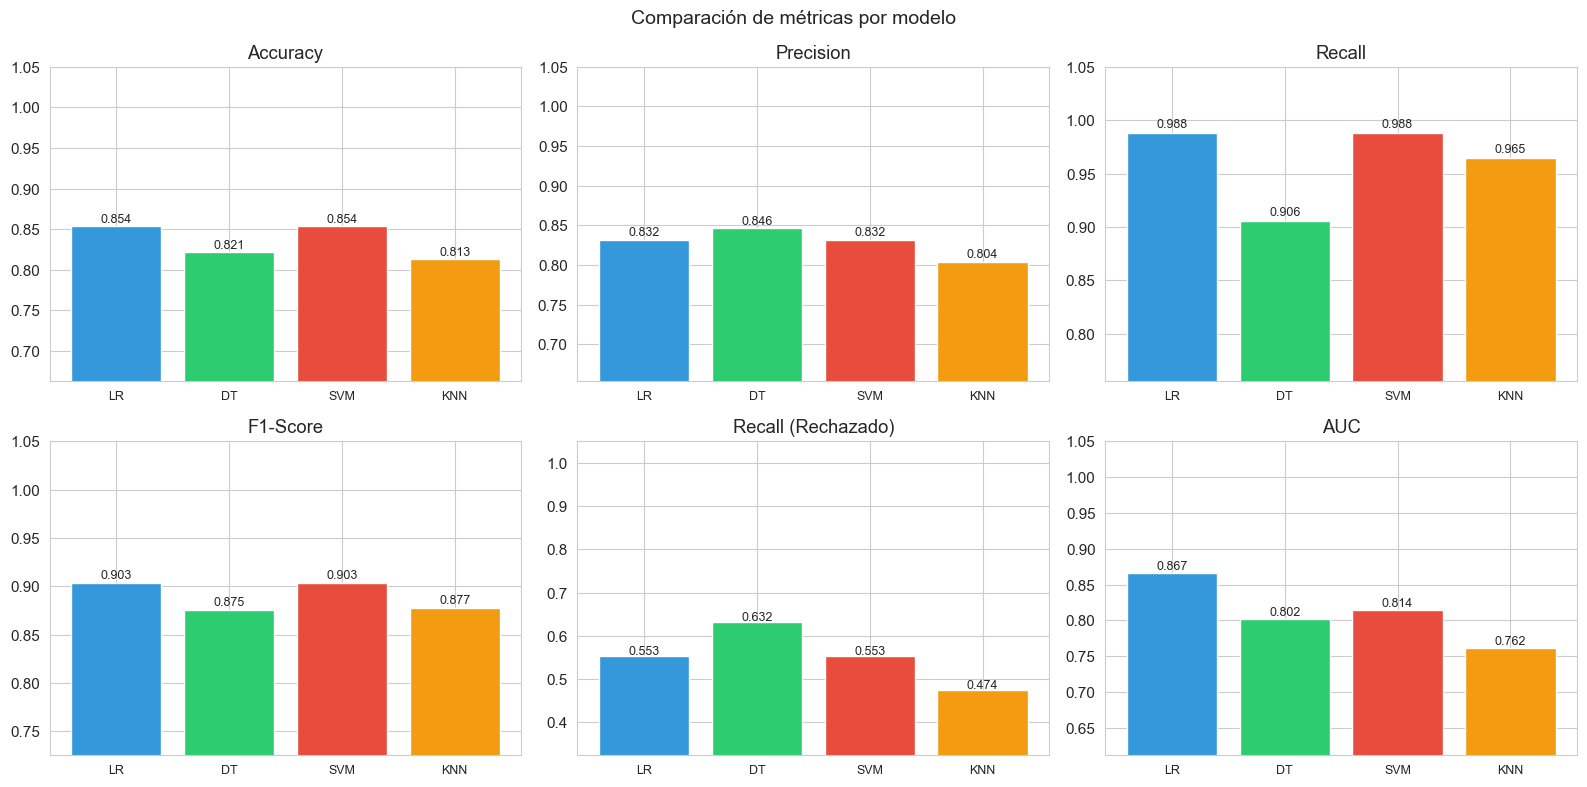

In [51]:
# 9.2  Gráfico de barras comparativo
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Recall (Rechazado)', 'AUC']
colors_models = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
short_names = ['LR', 'DT', 'SVM', 'KNN']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, metric in zip(axes.ravel(), metric_names):
    values = [all_metrics[m][metric] for m in all_metrics]
    ax.bar(range(len(values)), values, color=colors_models)
    ax.set_title(metric)
    ax.set_ylim(max(0, min(values) - 0.15), 1.05)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(short_names, fontsize=9)
    for i, v in enumerate(values):
        ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Comparación de métricas por modelo', fontsize=14)
plt.tight_layout()
plt.show()

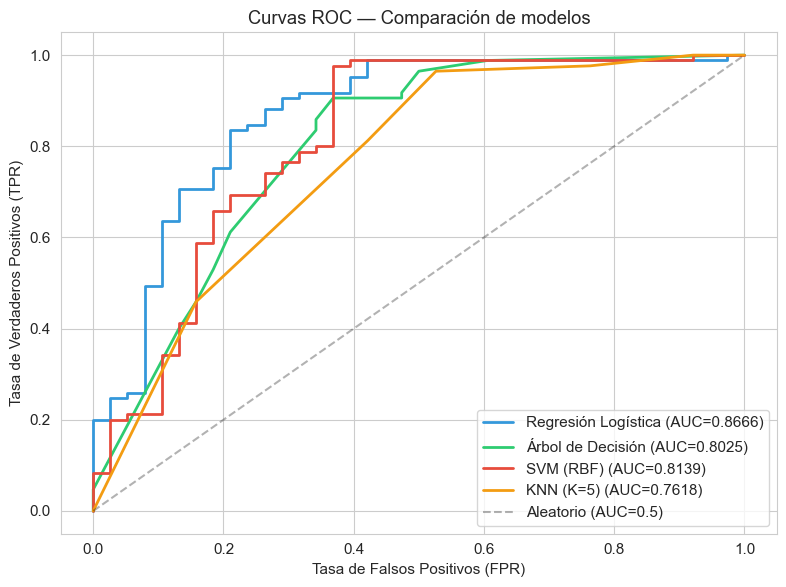

In [52]:
# 9.3  Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(8, 6))

for (name, model), color in zip(all_models.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, get_scores(model, X_test))
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC={auc(fpr, tpr):.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [53]:
# 9.4  Matriz de selección (criterios cualitativos + resultados medidos en test)
selection_matrix = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆'],
    'Recall Rechazado (test)': metrics_df['Recall (Rechazado)'].values,
    'AUC (test)': metrics_df['AUC'].values
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos ===')
selection_matrix

=== Matriz de Selección de Modelos ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers,Recall Rechazado (test),AUC (test)
Modelo,,,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆,0.5526,0.8666
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆,0.6316,0.8025
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆,0.5526,0.8139
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,0.4737,0.7618


### 9.5  Ejercicio 1 — Comparación de los modelos optimizados con GridSearchCV

In [54]:
# 9.5  Modelos optimizados vs modelos base
tuned_models = {name: grids[name].best_estimator_ for name in all_models}

rows = []
for name in all_models:
    rows.append({
        'Modelo': name,
        'Mejores parámetros': {k.replace('clf__', ''): v for k, v in grids[name].best_params_.items()},
        'F1 CV (optimizado)': grids[name].best_score_,
        'F1 test (base)': all_metrics[name]['F1-Score'],
        'F1 test (optimizado)': tuned_metrics[name]['F1-Score'],
        'Recall Rechazado (optimizado)': tuned_metrics[name]['Recall (Rechazado)'],
        'AUC (optimizado)': tuned_metrics[name]['AUC'],
    })
tuning_df = pd.DataFrame(rows).set_index('Modelo')
tuning_df['Δ F1 test'] = tuning_df['F1 test (optimizado)'] - tuning_df['F1 test (base)']

best_cv = tuning_df['F1 CV (optimizado)'].idxmax()
best_test = tuning_df['F1 test (optimizado)'].idxmax()
print(f'Mejor modelo optimizado por F1 en CV:   {best_cv} ({tuning_df.loc[best_cv, "F1 CV (optimizado)"]:.4f})')
print(f'Mejor modelo optimizado por F1 en test: {best_test} ({tuning_df.loc[best_test, "F1 test (optimizado)"]:.4f})')

tuning_df.round(4)

Mejor modelo optimizado por F1 en CV:   Regresión Logística (0.8699)
Mejor modelo optimizado por F1 en test: Regresión Logística (0.9032)


,Mejores parámetros,F1 CV (optimizado),F1 test (base),F1 test (optimizado),Recall Rechazado (optimizado),AUC (optimizado),Δ F1 test
Modelo,,,,,,,
Regresión Logística,{'C': 0.1},0.8699,0.9032,0.9032,0.5526,0.8638,0.0000
Árbol de Decisión,"{'max_depth': 3, 'min_samples_leaf': 1}",0.8636,0.8750,0.8984,0.5263,0.7375,0.0234
SVM (RBF),"{'C': 1, 'gamma': 0.01}",0.8699,0.9032,0.9032,0.5526,0.8211,0.0000
KNN (K=5),"{'n_neighbors': 15, 'weights': 'uniform'}",0.8413,0.8770,0.8426,0.2368,0.7729,-0.0344


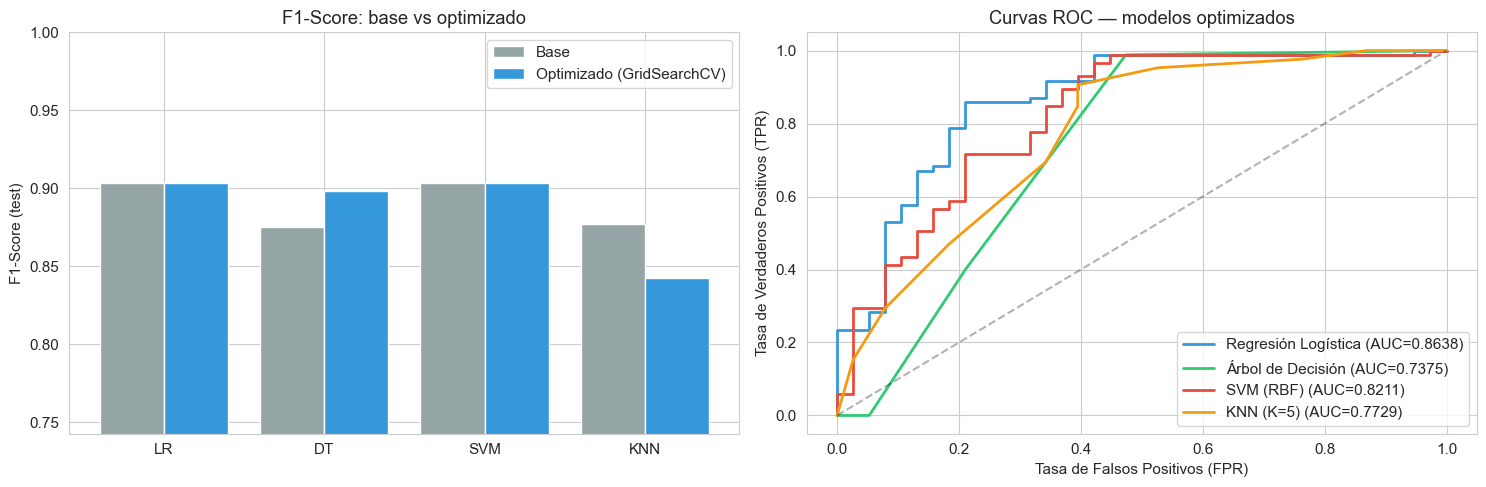

In [55]:
# 9.5b  Base vs optimizado (F1 en test) y curvas ROC de los modelos optimizados
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(all_models))
axes[0].bar(x - 0.2, tuning_df['F1 test (base)'], 0.4, label='Base', color='#95a5a6')
axes[0].bar(x + 0.2, tuning_df['F1 test (optimizado)'], 0.4, label='Optimizado (GridSearchCV)', color='#3498db')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names)
axes[0].set_ylabel('F1-Score (test)')
axes[0].set_ylim(max(0, tuning_df[['F1 test (base)', 'F1 test (optimizado)']].min().min() - 0.1), 1.0)
axes[0].set_title('F1-Score: base vs optimizado')
axes[0].legend()

for (name, model), color in zip(tuned_models.items(), colors_models):
    fpr, tpr, _ = roc_curve(y_test, get_scores(model, X_test))
    axes[1].plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curvas ROC — modelos optimizados')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### 9.6  Ejercicio 2 — SMOTE

`SMOTE` genera muestras sintéticas de la clase minoritaria (**Rechazado**) interpolando entre vecinos. Solo se aplica al conjunto de **entrenamiento**; el test permanece intacto.

Como `X_train` contiene texto y valores faltantes, SMOTE se aplica sobre los datos ya preprocesados (`X_res, y_res`). Para entrenar los 4 modelos se usa un Pipeline de `imblearn`, que aplica SMOTE solo al ajustar y nunca al predecir.

In [56]:
# 9.6a  SMOTE sobre los datos de entrenamiento preprocesados
X_train_prep = make_prep().fit_transform(X_train)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_prep, y_train)

print(f'Antes de SMOTE:   {X_train_prep.shape[0]} muestras → '
      f'Rechazado: {(y_train == 0).sum()}, Aprobado: {(y_train == 1).sum()}')
print(f'Después de SMOTE: {X_res.shape[0]} muestras → '
      f'Rechazado: {(y_res == 0).sum()}, Aprobado: {(y_res == 1).sum()}  (clases balanceadas)')

Antes de SMOTE:   491 muestras → Rechazado: 154, Aprobado: 337
Después de SMOTE: 674 muestras → Rechazado: 337, Aprobado: 337  (clases balanceadas)


In [57]:
# 9.6b  Los 4 modelos entrenados con SMOTE (mismos hiperparámetros que los modelos base)
base_clfs = {
    'Regresión Logística': lambda: LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión':   lambda: DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                                          min_samples_leaf=5, random_state=42),
    'SVM (RBF)':           lambda: SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'KNN (K=5)':           lambda: KNeighborsClassifier(n_neighbors=5),
}

smote_models = {}
for name, make_clf in base_clfs.items():
    pipe_s = ImbPipeline([
        ('prep', make_prep()),
        ('smote', SMOTE(random_state=42)),
        ('clf', make_clf())
    ])
    pipe_s.fit(X_train, y_train)
    smote_models[name] = pipe_s
    balance_results.setdefault(name, {})['SMOTE'] = test_metrics(pipe_s, X_test, y_test)

print('✓ Modelos con SMOTE entrenados')

✓ Modelos con SMOTE entrenados


### 9.7  Ejercicio 2 — Recall de la clase Rechazado: sin balanceo vs `class_weight` vs SMOTE

=== Recall (Rechazado) — test set  (NaN = no aplica: KNN no soporta class_weight) ===


,Base,class_weight,SMOTE
Regresión Logística,0.5526,0.7368,0.7368
Árbol de Decisión,0.6316,0.6053,0.7368
SVM (RBF),0.5526,0.6316,0.6316
KNN (K=5),0.4737,NaN,0.5789



=== F1-Score (Aprobado) — test set ===


,Base,class_weight,SMOTE
Regresión Logística,0.9032,0.8824,0.8953
Árbol de Decisión,0.8750,0.8439,0.7975
SVM (RBF),0.9032,0.9000,0.8621
KNN (K=5),0.8770,NaN,0.7976



=== Accuracy — test set ===


,Base,class_weight,SMOTE
Regresión Logística,0.8537,0.8374,0.8537
Árbol de Decisión,0.8211,0.7805,0.7398
SVM (RBF),0.8537,0.8537,0.8049
KNN (K=5),0.8130,NaN,0.7236


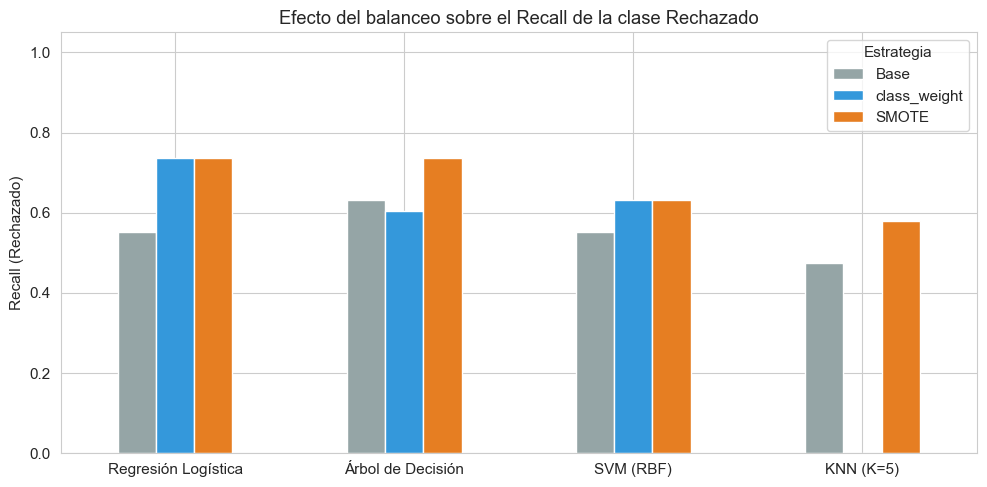

Lectura: subir el Recall de Rechazado suele costar Precision/Accuracy (más solicitudes buenas rechazadas). Compara las tres tablas antes de decidir.


In [58]:
# 9.7  Comparación final del Recall de la clase Rechazado
variants = ['Base', 'class_weight', 'SMOTE']

recall_tab = pd.DataFrame(
    {name: {v: balance_results[name].get(v, {}).get('Recall (Rechazado)', np.nan) for v in variants}
     for name in balance_results}
).T
f1_tab = pd.DataFrame(
    {name: {v: balance_results[name].get(v, {}).get('F1-Score', np.nan) for v in variants}
     for name in balance_results}
).T
acc_tab = pd.DataFrame(
    {name: {v: balance_results[name].get(v, {}).get('Accuracy', np.nan) for v in variants}
     for name in balance_results}
).T

print('=== Recall (Rechazado) — test set  (NaN = no aplica: KNN no soporta class_weight) ===')
display(recall_tab.round(4))
print('\n=== F1-Score (Aprobado) — test set ===')
display(f1_tab.round(4))
print('\n=== Accuracy — test set ===')
display(acc_tab.round(4))

recall_tab.plot(kind='bar', figsize=(10, 5), color=['#95a5a6', '#3498db', '#e67e22'])
plt.ylabel('Recall (Rechazado)')
plt.title('Efecto del balanceo sobre el Recall de la clase Rechazado')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title='Estrategia')
plt.tight_layout()
plt.show()

print('Lectura: subir el Recall de Rechazado suele costar Precision/Accuracy '
      '(más solicitudes buenas rechazadas). Compara las tres tablas antes de decidir.')

---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Reg. Logística** | Interpretable, probabilístico, rápido | Asume linealidad en log-odds | Clasificación binaria con necesidad de interpretabilidad (p. ej. justificar una decisión de crédito) |
| **Árbol de Decisión** | Explicable, maneja tipos mixtos | Propenso a sobreajuste sin poda | Reglas de negocio, explicabilidad ante stakeholders |
| **SVM** | Efectivo en alta dimensión, robusto al ruido | Lento con muchos datos, difícil de interpretar | Datasets de dimensión media-alta, márgenes claros |
| **KNN** | Simple, no paramétrico, flexible | Lento en predicción, maldición de la dimensionalidad, sin `class_weight` | Datasets pequeños-medianos con features normalizadas |

**Criterio de selección final:** en este problema de crédito, el error más costoso es **aprobar una solicitud que debía rechazarse**. Por eso se prioriza el **Recall de la clase Rechazado**, sin dejar caer el F1 (para no rechazar de más a buenos solicitantes). La regla exacta y el modelo elegido se calculan en la sección 12.

---
## 11. Ejercicio 3 — Modelos adicionales

El dataset propio ya es Loan Prediction (614 registros y 11 features: cumple el mínimo de 500 registros y 5 features). A los 4 modelos anteriores se suman **3 modelos adicionales**: Random Forest, Gradient Boosting y Naive Bayes.

Random Forest — CV 5-fold
  Train Accuracy:     1.0000
  Accuracy:           0.7698 ± 0.0553
  F1-Score:           0.8466 ± 0.0391
  Recall (Aprobado):  0.9291 ± 0.0618
  Recall (Rechazado): 0.4219 ± 0.0905

=== Random Forest ===
  Accuracy: 0.8130
  Precision: 0.8370
  Recall: 0.9059
  F1-Score: 0.8701
  Recall (Rechazado): 0.6053
  AUC: 0.7983


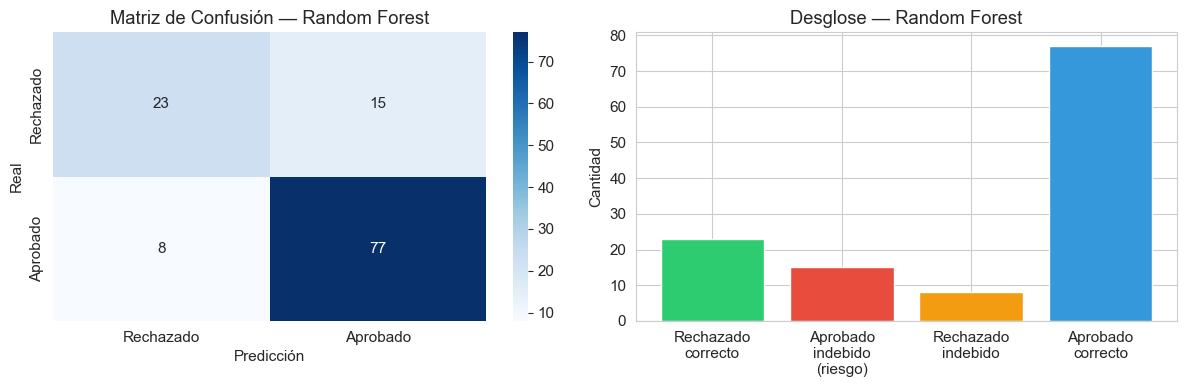


  Aprobado indebido (real Rechazado → predicho Aprobado): 15
  Rechazado indebido (real Aprobado → predicho Rechazado): 8

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.74      0.61      0.67        38
    Aprobado       0.84      0.91      0.87        85

    accuracy                           0.81       123
   macro avg       0.79      0.76      0.77       123
weighted avg       0.81      0.81      0.81       123

----------------------------------------------------------------------
Gradient Boosting — CV 5-fold
  Train Accuracy:     0.9119
  Accuracy:           0.7657 ± 0.0286
  F1-Score:           0.8432 ± 0.0212
  Recall (Aprobado):  0.9200 ± 0.0453
  Recall (Rechazado): 0.4286 ± 0.0625

=== Gradient Boosting ===
  Accuracy: 0.8049
  Precision: 0.8211
  Recall: 0.9176
  F1-Score: 0.8667
  Recall (Rechazado): 0.5526
  AUC: 0.7539


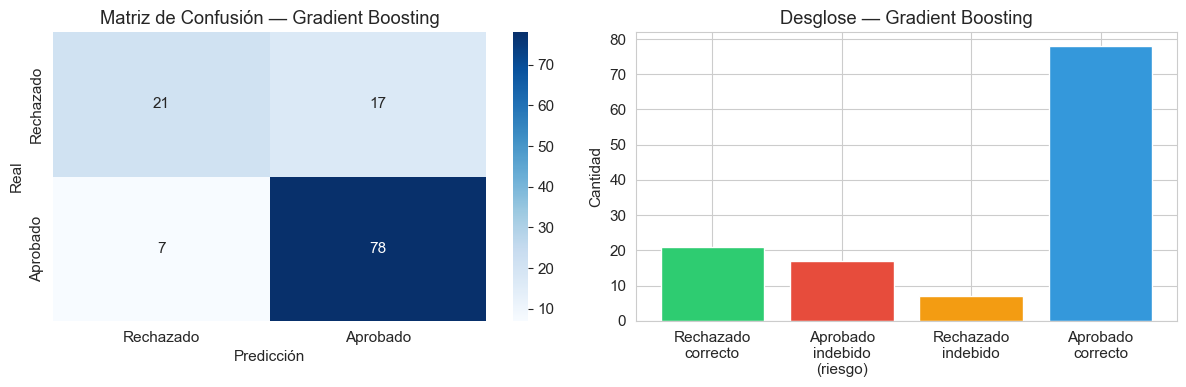


  Aprobado indebido (real Rechazado → predicho Aprobado): 17
  Rechazado indebido (real Aprobado → predicho Rechazado): 7

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.75      0.55      0.64        38
    Aprobado       0.82      0.92      0.87        85

    accuracy                           0.80       123
   macro avg       0.79      0.74      0.75       123
weighted avg       0.80      0.80      0.80       123

----------------------------------------------------------------------
Naive Bayes — CV 5-fold
  Train Accuracy:     0.7989
  Accuracy:           0.7922 ± 0.0444
  F1-Score:           0.8654 ± 0.0265
  Recall (Aprobado):  0.9704 ± 0.0264
  Recall (Rechazado): 0.4028 ± 0.1135

=== Naive Bayes ===
  Accuracy: 0.8537
  Precision: 0.8317
  Recall: 0.9882
  F1-Score: 0.9032
  Recall (Rechazado): 0.5526
  AUC: 0.8331


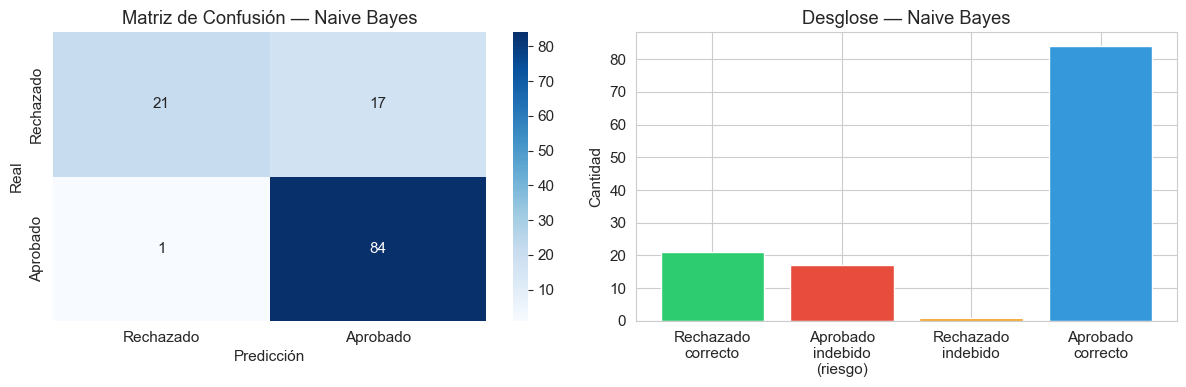


  Aprobado indebido (real Rechazado → predicho Aprobado): 17
  Rechazado indebido (real Aprobado → predicho Rechazado): 1

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.95      0.55      0.70        38
    Aprobado       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

----------------------------------------------------------------------


In [62]:
# 11.1  Entrenamiento y evaluación de los modelos adicionales
extra_models = {
    'Random Forest': Pipeline([('prep', make_prep()),
                               ('clf', RandomForestClassifier(n_estimators=300, random_state=42))]),
    'Gradient Boosting': Pipeline([('prep', make_prep()),
                                   ('clf', GradientBoostingClassifier(random_state=42))]),
    'Naive Bayes': Pipeline([('prep', make_prep()),
                             ('clf', GaussianNB())]),
}

extra_metrics = {}
for name, model in extra_models.items():
    cv_e = cross_validate(model, X_train, y_train, cv=skf, scoring=SCORING, return_train_score=True)
    cv_summary(cv_e, name)
    model.fit(X_train, y_train)
    print()
    extra_metrics[name] = eval_classifier(model, X_train, y_train, X_test, y_test, name)
    print('-' * 70)

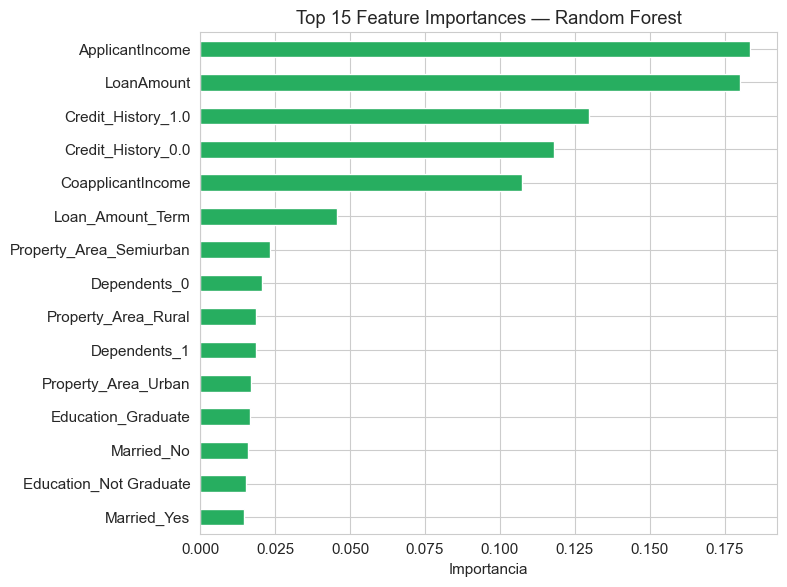

In [64]:
# 11.2  Importancia de features — Random Forest
rf_imp = pd.Series(
    extra_models['Random Forest'].named_steps['clf'].feature_importances_,
    index=get_feature_names(extra_models['Random Forest'])
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
rf_imp.tail(15).plot(kind='barh', ax=ax, color='#27ae60')
ax.set_title('Top 15 Feature Importances — Random Forest')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

=== Tabla comparativa — 7 modelos (Test Set) ===


,Accuracy,Precision,Recall,F1-Score,Recall (Rechazado),AUC
Regresión Logística,0.8537,0.8317,0.9882,0.9032,0.5526,0.8666
Árbol de Decisión,0.8211,0.8462,0.9059,0.8750,0.6316,0.8025
SVM (RBF),0.8537,0.8317,0.9882,0.9032,0.5526,0.8139
KNN (K=5),0.8130,0.8039,0.9647,0.8770,0.4737,0.7618
Random Forest,0.8130,0.8370,0.9059,0.8701,0.6053,0.7983
Gradient Boosting,0.8049,0.8211,0.9176,0.8667,0.5526,0.7539
Naive Bayes,0.8537,0.8317,0.9882,0.9032,0.5526,0.8331


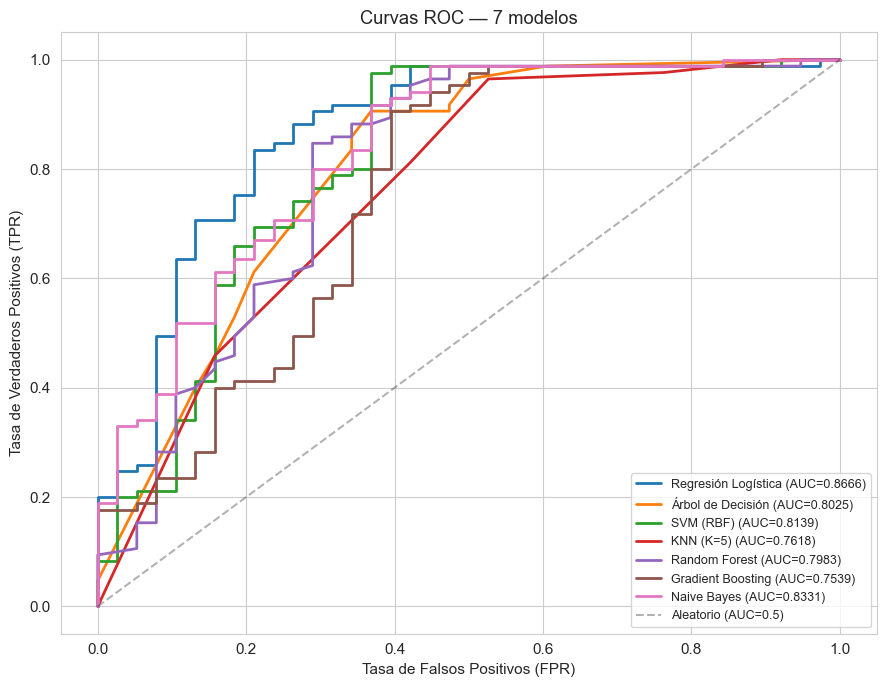

In [65]:
# 11.3  Tabla y curvas ROC de los 7 modelos (configuración base)
models_7 = {**all_models, **extra_models}
metrics_7 = pd.DataFrame({n: test_metrics(m, X_test, y_test) for n, m in models_7.items()}).T.round(4)
print('=== Tabla comparativa — 7 modelos (Test Set) ===')
display(metrics_7)

fig, ax = plt.subplots(figsize=(9, 7))
palette = plt.cm.tab10(np.arange(len(models_7)))
for (name, model), color in zip(models_7.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, get_scores(model, X_test))
    ax.plot(fpr, tpr, linewidth=2, color=color, label=f'{name} (AUC={auc(fpr, tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Aleatorio (AUC=0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — 7 modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [66]:
# 11.4  Matriz de selección ampliada (7 modelos)
selection_matrix_7 = pd.DataFrame({
    'Modelo': ['Reg. Logística', 'Árbol de Decisión', 'SVM (RBF)', 'KNN',
               'Random Forest', 'Gradient Boosting', 'Naive Bayes'],
    'Precisión predictiva': ['★★★★☆', '★★★☆☆', '★★★★★', '★★★★☆', '★★★★☆', '★★★★★', '★★★☆☆'],
    'Velocidad (train+pred)': ['★★★★★', '★★★★☆', '★★★☆☆', '★★★★★', '★★★☆☆', '★★☆☆☆', '★★★★★'],
    'Interpretabilidad': ['★★★★☆', '★★★★★', '★★☆☆☆', '★★★☆☆', '★★★☆☆', '★★☆☆☆', '★★★☆☆'],
    'Escalabilidad': ['★★★★★', '★★★★☆', '★★☆☆☆', '★★☆☆☆', '★★★★☆', '★★★☆☆', '★★★★★'],
    'Robustez a outliers': ['★★★☆☆', '★★★★☆', '★★★★☆', '★★☆☆☆', '★★★★★', '★★★★☆', '★★★☆☆'],
    'Recall Rechazado (test)': metrics_7['Recall (Rechazado)'].values,
    'F1-Score (test)': metrics_7['F1-Score'].values,
    'AUC (test)': metrics_7['AUC'].values
}).set_index('Modelo')

print('=== Matriz de Selección de Modelos (7 modelos) ===')
selection_matrix_7

=== Matriz de Selección de Modelos (7 modelos) ===


,Precisión predictiva,Velocidad (train+pred),Interpretabilidad,Escalabilidad,Robustez a outliers,Recall Rechazado (test),F1-Score (test),AUC (test)
Modelo,,,,,,,,
Reg. Logística,★★★★☆,★★★★★,★★★★☆,★★★★★,★★★☆☆,0.5526,0.9032,0.8666
Árbol de Decisión,★★★☆☆,★★★★☆,★★★★★,★★★★☆,★★★★☆,0.6316,0.8750,0.8025
SVM (RBF),★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,★★★★☆,0.5526,0.9032,0.8139
KNN,★★★★☆,★★★★★,★★★☆☆,★★☆☆☆,★★☆☆☆,0.4737,0.8770,0.7618
Random Forest,★★★★☆,★★★☆☆,★★★☆☆,★★★★☆,★★★★★,0.6053,0.8701,0.7983
Gradient Boosting,★★★★★,★★☆☆☆,★★☆☆☆,★★★☆☆,★★★★☆,0.5526,0.8667,0.7539
Naive Bayes,★★★☆☆,★★★★★,★★★☆☆,★★★★★,★★★☆☆,0.5526,0.9032,0.8331


---
## 12. Justificación del mejor modelo

Se reúnen **todas** las variantes evaluadas (base, optimizadas con GridSearchCV, con `class_weight`, con SMOTE y modelos adicionales) y se aplica el criterio definido en la sección 10:

1. Se descartan las variantes cuyo **F1-Score** quede más de 0.05 por debajo del mejor F1 (evita elegir un modelo que "rechaza todo").
2. Entre las restantes, se elige la de mayor **Recall (Rechazado)**; el AUC desempata.

*Nota:* igual que en el notebook original, la comparación final usa el conjunto de test.

In [67]:
# ══ EJERCICIO 3 · Dataset propio + modelos adicionales ═════════════
# 12.1  Ranking de todas las variantes
final_rows = {}
for name, m in all_metrics.items():
    final_rows[f'{name} · base'] = m
for name, m in tuned_metrics.items():
    final_rows[f'{name} · GridSearchCV'] = m
for name, d in balance_results.items():
    for variant in ['class_weight', 'SMOTE']:
        if variant in d:
            final_rows[f'{name} · {variant}'] = d[variant]
for name, m in extra_metrics.items():
    final_rows[f'{name} · base'] = m

final_df = pd.DataFrame(final_rows).T.round(4)

best_f1 = final_df['F1-Score'].max()
candidates = final_df[final_df['F1-Score'] >= best_f1 - 0.05]
ranking = candidates.sort_values(['Recall (Rechazado)', 'AUC'], ascending=False)
winner = ranking.index[0]

print(f'Variantes evaluadas: {len(final_df)}')
print(f'Mejor F1-Score: {best_f1:.4f} → candidatas (F1 ≥ {best_f1 - 0.05:.4f}): {len(candidates)}')
print(f'\n★ Modelo recomendado: {winner}')
print(f'   Recall (Rechazado) = {ranking.loc[winner, "Recall (Rechazado)"]:.4f} | '
      f'F1 = {ranking.loc[winner, "F1-Score"]:.4f} | '
      f'Accuracy = {ranking.loc[winner, "Accuracy"]:.4f} | '
      f'AUC = {ranking.loc[winner, "AUC"]:.4f}')

print('\n=== Ranking de candidatas ===')
ranking

Variantes evaluadas: 18
Mejor F1-Score: 0.9032 → candidatas (F1 ≥ 0.8532): 14

★ Modelo recomendado: Regresión Logística · SMOTE
   Recall (Rechazado) = 0.7368 | F1 = 0.8953 | Accuracy = 0.8537 | AUC = 0.8777

=== Ranking de candidatas ===


,Accuracy,Precision,Recall,F1-Score,Recall (Rechazado),AUC
Regresión Logística · SMOTE,0.8537,0.8851,0.9059,0.8953,0.7368,0.8777
Regresión Logística · class_weight,0.8374,0.8824,0.8824,0.8824,0.7368,0.8721
SVM (RBF) · class_weight,0.8537,0.8526,0.9529,0.9000,0.6316,0.8087
SVM (RBF) · SMOTE,0.8049,0.8427,0.8824,0.8621,0.6316,0.8037
Árbol de Decisión · base,0.8211,0.8462,0.9059,0.8750,0.6316,0.8025
Random Forest · base,0.8130,0.8370,0.9059,0.8701,0.6053,0.7983
Regresión Logística · base,0.8537,0.8317,0.9882,0.9032,0.5526,0.8666
Regresión Logística · GridSearchCV,0.8537,0.8317,0.9882,0.9032,0.5526,0.8638
Naive Bayes · base,0.8537,0.8317,0.9882,0.9032,0.5526,0.8331
SVM (RBF) · GridSearchCV,0.8537,0.8317,0.9882,0.9032,0.5526,0.8211


In [68]:
# ══ EJERCICIO 3 · Dataset propio + modelos adicionales ═════════════
# 12.2  Todas las variantes (tabla completa)
final_df.sort_values('Recall (Rechazado)', ascending=False)

,Accuracy,Precision,Recall,F1-Score,Recall (Rechazado),AUC
Regresión Logística · SMOTE,0.8537,0.8851,0.9059,0.8953,0.7368,0.8777
Regresión Logística · class_weight,0.8374,0.8824,0.8824,0.8824,0.7368,0.8721
Árbol de Decisión · SMOTE,0.7398,0.8630,0.7412,0.7975,0.7368,0.8042
Árbol de Decisión · base,0.8211,0.8462,0.9059,0.8750,0.6316,0.8025
SVM (RBF) · SMOTE,0.8049,0.8427,0.8824,0.8621,0.6316,0.8037
SVM (RBF) · class_weight,0.8537,0.8526,0.9529,0.9000,0.6316,0.8087
Random Forest · base,0.8130,0.8370,0.9059,0.8701,0.6053,0.7983
Árbol de Decisión · class_weight,0.7805,0.8295,0.8588,0.8439,0.6053,0.7605
KNN (K=5) · SMOTE,0.7236,0.8072,0.7882,0.7976,0.5789,0.7625
Regresión Logística · base,0.8537,0.8317,0.9882,0.9032,0.5526,0.8666


=== Regresión Logística · SMOTE ===
  Accuracy: 0.8537
  Precision: 0.8851
  Recall: 0.9059
  F1-Score: 0.8953
  Recall (Rechazado): 0.7368
  AUC: 0.8777


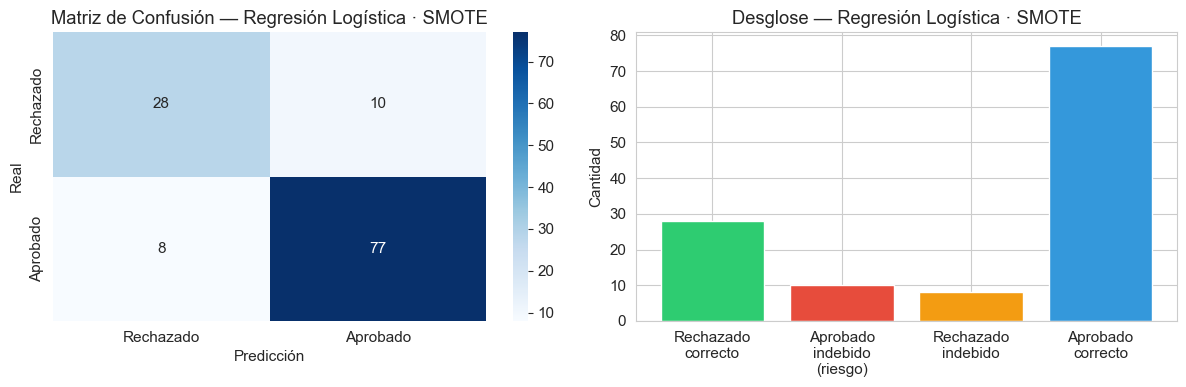


  Aprobado indebido (real Rechazado → predicho Aprobado): 10
  Rechazado indebido (real Aprobado → predicho Rechazado): 8

Reporte completo:
              precision    recall  f1-score   support

   Rechazado       0.78      0.74      0.76        38
    Aprobado       0.89      0.91      0.90        85

    accuracy                           0.85       123
   macro avg       0.83      0.82      0.83       123
weighted avg       0.85      0.85      0.85       123



In [69]:
# 12.3  Matriz de confusión del modelo recomendado
all_variants = {}
all_variants.update({f'{n} · base': m for n, m in all_models.items()})
all_variants.update({f'{n} · GridSearchCV': grids[n].best_estimator_ for n in grids})
all_variants.update({f'{n} · class_weight': m for n, m in
                     [('Regresión Logística', lr_bal), ('Árbol de Decisión', dt_bal), ('SVM (RBF)', svm_bal)]})
all_variants.update({f'{n} · SMOTE': m for n, m in smote_models.items()})
all_variants.update({f'{n} · base': m for n, m in extra_models.items()})

best_model = all_variants[winner]
_ = eval_classifier(best_model, X_train, y_train, X_test, y_test, winner)

### Redacción de la justificación

Con los resultados anteriores, la justificación del modelo elegido debe cubrir:
- **Métrica prioritaria:** Recall de la clase Rechazado (detectar solicitudes de riesgo), respaldado por F1 y AUC para confirmar que no se sacrifica el desempeño general.
- **Efecto del balanceo:** si `class_weight` o SMOTE elevaron el Recall de Rechazado y a qué costo en Precision/Accuracy (tablas de 9.7).
- **Efecto de la optimización:** si GridSearchCV mejoró el F1 respecto del modelo base (tabla de 9.5).
- **Trade-offs cualitativos:** interpretabilidad y velocidad (matriz de selección 11.4). Si dos modelos rinden parecido, es preferible el más interpretable, porque una decisión de crédito debe poder explicarse al solicitante.

---
## 11. Ejercicios propuestos

### Ejercicio 1 — Optimización con GridSearchCV
Para cada modelo, realice una búsqueda exhaustiva de hiperparámetros con `GridSearchCV(cv=5, scoring='f1')`. Parámetros sugeridos:
- **LogisticRegression:** C=[0.01, 0.1, 1, 10, 100]
- **DecisionTree:** max_depth=[3,5,7,10,None], min_samples_leaf=[1,5,10]
- **SVM:** C=[0.1,1,10], gamma=[0.001,0.01,0.1]
- **KNN:** n_neighbors=[3,5,9,15,21], weights=['uniform','distance']

Compare los mejores modelos optimizados.

### Ejercicio 2 — Manejo de desbalance con class_weight y SMOTE
Entrene los 4 modelos con `class_weight='balanced'`. Compare Recall de la clase maligna con y sin balanceo. Además, aplique SMOTE:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
```

### Ejercicio 3 — Dataset propio
Seleccione un dataset de clasificación de Kaggle/UCI (mín. 500 registros, 5 features). Aplique los 4 modelos + al menos 1 adicional (Random Forest, Gradient Boosting o Naive Bayes). Documente métricas, curvas ROC, matriz de selección y justificación del mejor modelo.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*